БЛОК 1: ПРОВЕРКА АУДИОФАЙЛОВ И УСТАНОВКА ЗАВИСИМОСТЕЙ
✅ librosa уже установлен
✅ torchaudio уже установлен

✅ Библиотеки импортированы

🖥️  Устройство: cuda
   GPU: NVIDIA GeForce RTX 3050 Laptop GPU
   Память: 4.3 GB

📁 Проверка папки: genres_original
✅ Папка найдена

📊 Найденные жанры (10):
   • blues: 100 файлов
     └─ Пример: blues.00000.wav (1.3 MB)
   • classical: 100 файлов
     └─ Пример: classical.00000.wav (1.3 MB)
   • country: 100 файлов
     └─ Пример: country.00000.wav (1.3 MB)
   • disco: 100 файлов
     └─ Пример: disco.00000.wav (1.3 MB)
   • hiphop: 100 файлов
     └─ Пример: hiphop.00000.wav (1.3 MB)
   • jazz: 100 файлов
     └─ Пример: jazz.00000.wav (1.3 MB)
   • metal: 100 файлов
     └─ Пример: metal.00000.wav (1.3 MB)
   • pop: 100 файлов
     └─ Пример: pop.00000.wav (1.3 MB)
   • reggae: 100 файлов
     └─ Пример: reggae.00000.wav (1.3 MB)
   • rock: 100 файлов
     └─ Пример: rock.00000.wav (1.3 MB)

📈 ИТОГО: 1000 аудиофайлов
   Жанров: 10
   В среднем: 100

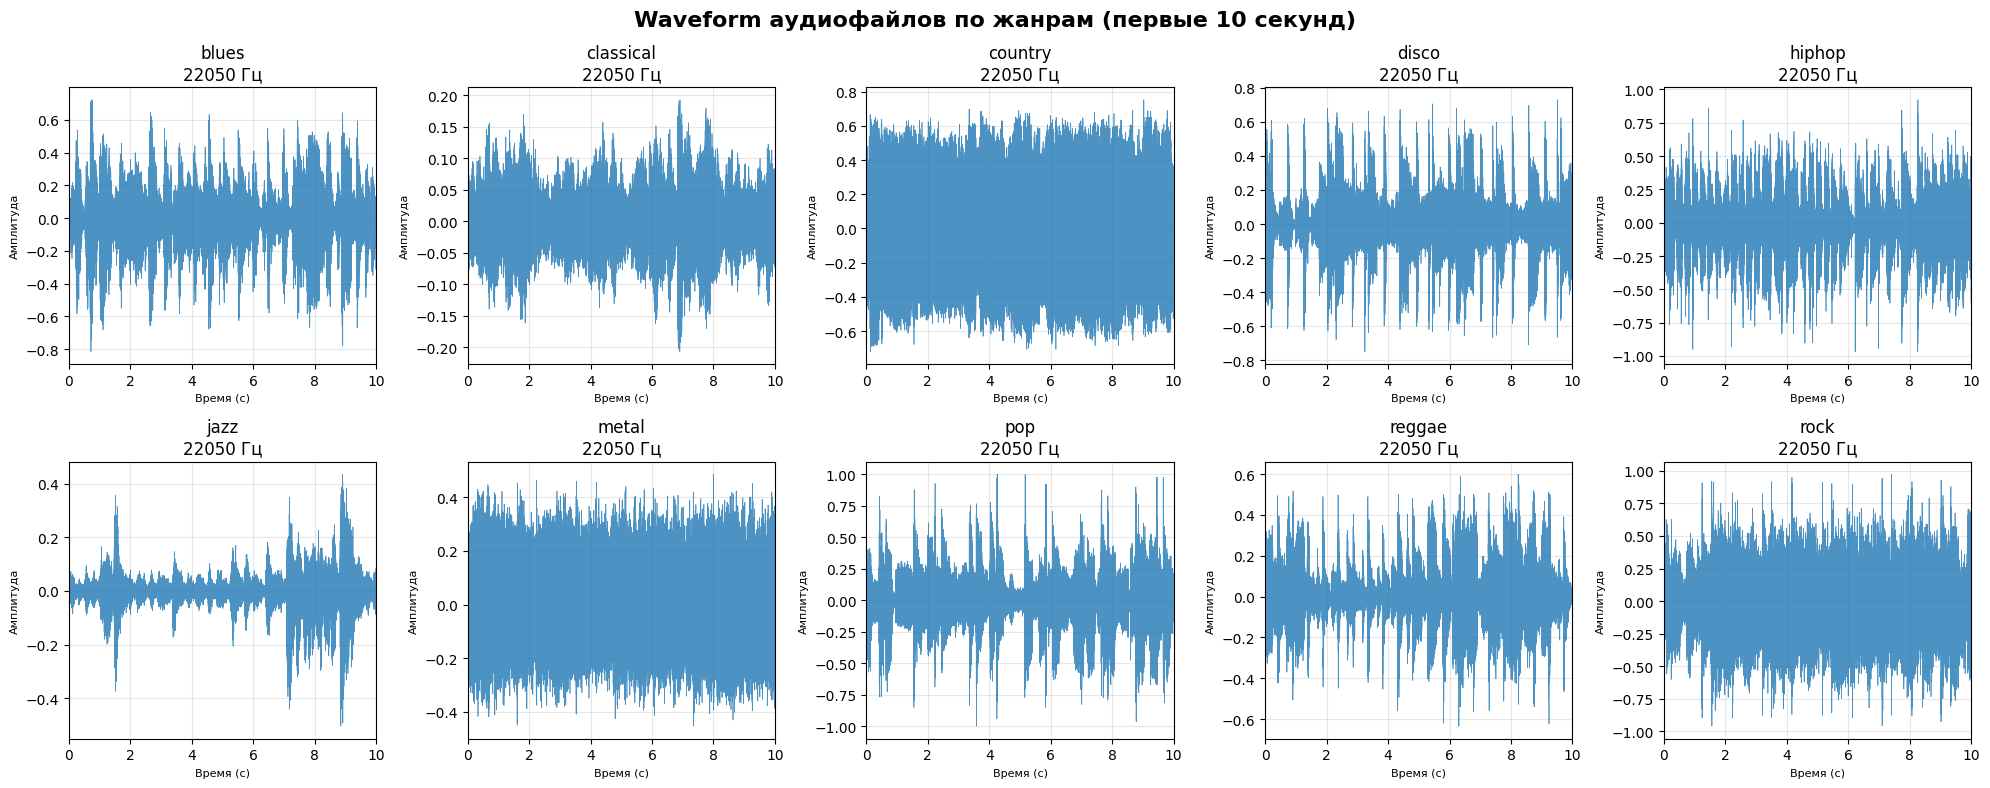

✅ Waveform сохранены в audio_waveforms.png


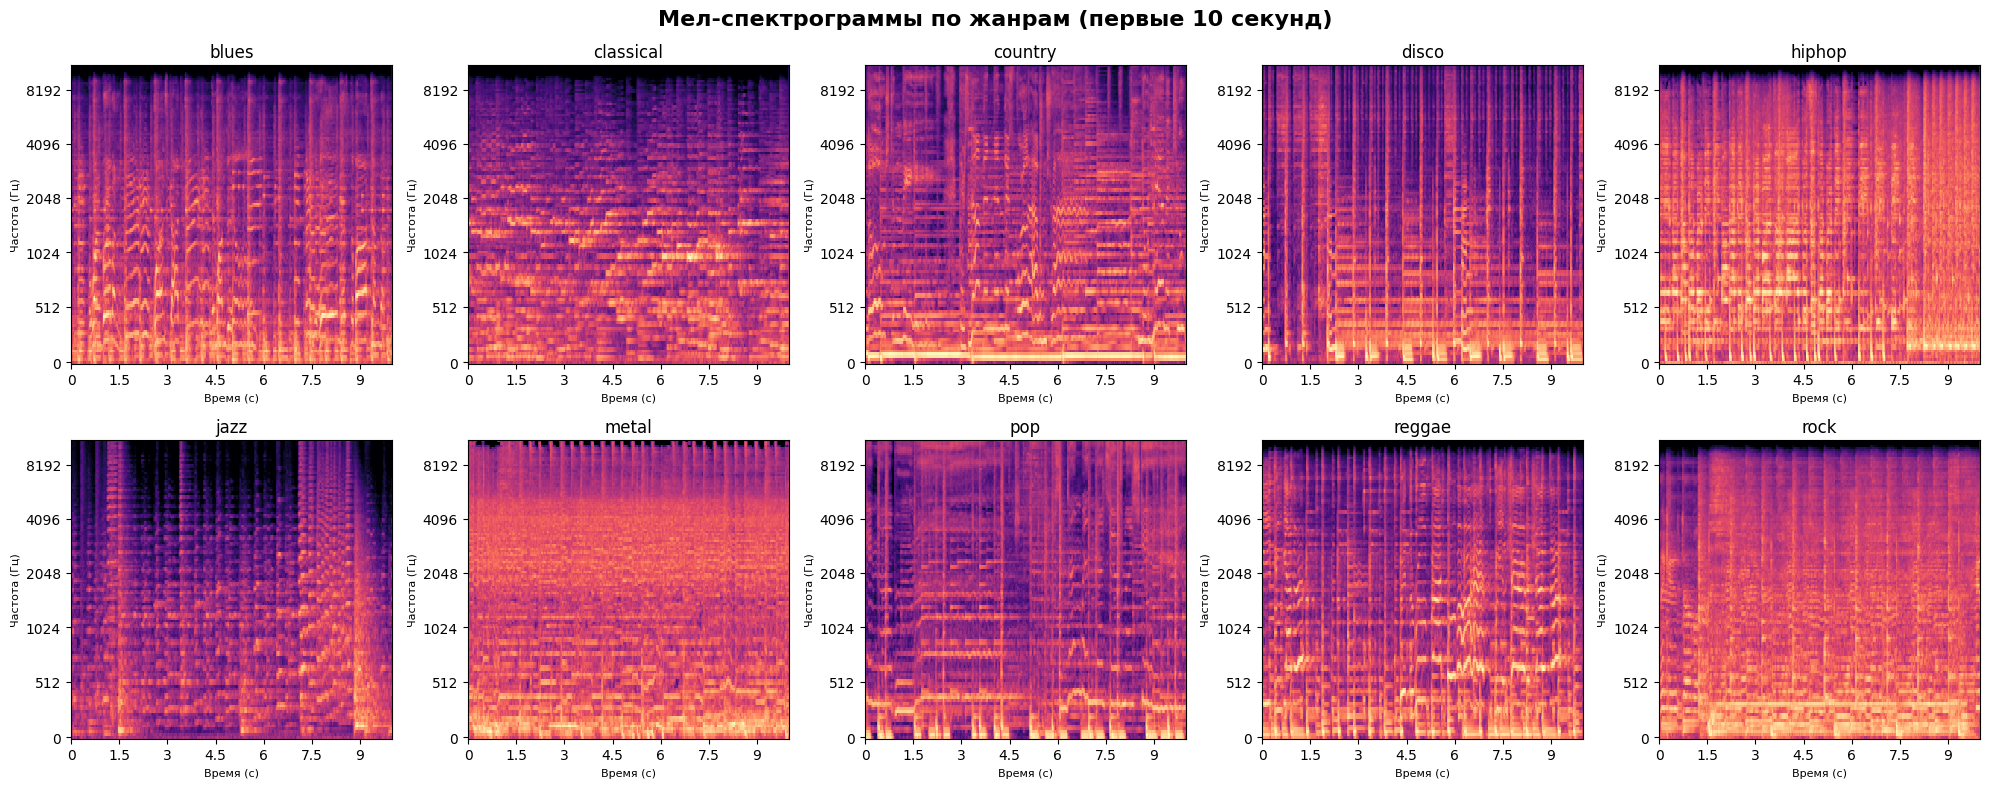

✅ Мел-спектрограммы сохранены в audio_melspectrograms.png

💾 Информация сохранена в audio_info.pth

⚙️  ПАРАМЕТРЫ ДЛЯ СОЗДАНИЯ СПЕКТРОГРАММ:

   Мы можем настроить:
   
   1. n_mels = 128     # количество мел-фильтров (высота)
   2. hop_length = 512 # шаг окна (ширина)
   3. win_length = 2048 # размер окна
   4. fmax = sr/2      # максимальная частота
   5. duration = 30    # длительность трека (сек)
   6. target_size = (224, 224) # размер изображения для CNN
   
   Это даст спектрограмму размером примерно (128, 1293) -> (224, 224)


✅ БЛОК 1 ВЫПОЛНЕН

➡️ Следующий шаг: БЛОК 2 - СОЗДАНИЕ СПЕКТРОГРАММ ИЗ АУДИО


In [1]:
# БЛОК 1 - ПРОВЕРКА АУДИОФАЙЛОВ
# ВЫПОЛНЯТЬ ПЕРВЫМ

print("="*70)
print("БЛОК 1: ПРОВЕРКА АУДИОФАЙЛОВ И УСТАНОВКА ЗАВИСИМОСТЕЙ")
print("="*70)

# 1.1 Установка необходимых библиотек (если нет)
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import librosa
    print("✅ librosa уже установлен")
except ImportError:
    print("📦 Устанавливаем librosa...")
    install_package('librosa')
    import librosa
    print("✅ librosa установлен")

try:
    import torchaudio
    print("✅ torchaudio уже установлен")
except ImportError:
    print("📦 Устанавливаем torchaudio...")
    install_package('torchaudio')
    import torchaudio
    print("✅ torchaudio установлен")

# 1.2 Импорты
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import librosa
import librosa.display
import torchaudio
import warnings
warnings.filterwarnings('ignore')

print("\n✅ Библиотеки импортированы")

# 1.3 Проверка GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️  Устройство: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Память: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# 1.4 Проверка наличия папки с аудиофайлами
audio_path = 'genres_original'
print(f"\n📁 Проверка папки: {audio_path}")

if not os.path.exists(audio_path):
    print(f"❌ Папка {audio_path} не найдена!")
    print("   Убедитесь, что вы скачали датасет с Kaggle")
    print("   Папка должна содержать 10 подпапок с жанрами")
    raise FileNotFoundError(f"Папка {audio_path} не найдена")
else:
    print(f"✅ Папка найдена")

# 1.5 Проверка структуры папок
genres = sorted([d for d in os.listdir(audio_path) 
                 if os.path.isdir(os.path.join(audio_path, d))])
print(f"\n📊 Найденные жанры ({len(genres)}):")

total_audio_files = 0
genre_audio_counts = {}

for genre in genres:
    genre_path = os.path.join(audio_path, genre)
    audio_files = [f for f in os.listdir(genre_path) 
                   if f.lower().endswith(('.wav', '.mp3', '.flac', '.m4a'))]
    count = len(audio_files)
    genre_audio_counts[genre] = count
    total_audio_files += count
    print(f"   • {genre}: {count} файлов")
    
    # Проверяем первый файл для примера
    if count > 0:
        first_file = audio_files[0]
        file_path = os.path.join(genre_path, first_file)
        file_size = os.path.getsize(file_path) / (1024 * 1024)  # MB
        print(f"     └─ Пример: {first_file} ({file_size:.1f} MB)")

print(f"\n📈 ИТОГО: {total_audio_files} аудиофайлов")
print(f"   Жанров: {len(genres)}")
print(f"   В среднем: {total_audio_files/len(genres):.0f} на жанр")

# 1.6 Анализ одного аудиофайла
print("\n🔍 АНАЛИЗ АУДИОФАЙЛА:")
sample_genre = genres[0]
sample_genre_path = os.path.join(audio_path, sample_genre)
sample_file = os.listdir(sample_genre_path)[0]
sample_path = os.path.join(sample_genre_path, sample_file)

# Загружаем аудио
y, sr = librosa.load(sample_path, duration=30)  # загружаем первые 30 секунд
duration = librosa.get_duration(filename=sample_path)

print(f"\n   Файл: {sample_file}")
print(f"   Жанр: {sample_genre}")
print(f"   Длительность: {duration:.1f} сек")
print(f"   Частота дискретизации: {sr} Гц")
print(f"   Форма сигнала: {y.shape}")
print(f"   Диапазон значений: [{y.min():.3f}, {y.max():.3f}]")

# 1.7 Визуализация waveform
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, genre in enumerate(genres[:10]):
    genre_path = os.path.join(audio_path, genre)
    audio_files = [f for f in os.listdir(genre_path) 
                   if f.lower().endswith(('.wav', '.mp3', '.flac', '.m4a'))]
    
    if audio_files:
        file_path = os.path.join(genre_path, audio_files[0])
        y, sr = librosa.load(file_path, duration=10)  # 10 секунд для визуализации
        
        # Временная шкала
        time = np.linspace(0, len(y)/sr, len(y))
        
        axes[idx].plot(time, y, alpha=0.8, linewidth=0.5)
        axes[idx].set_title(f"{genre}\n{sr} Гц", fontsize=12)
        axes[idx].set_xlabel("Время (с)", fontsize=8)
        axes[idx].set_ylabel("Амплитуда", fontsize=8)
        axes[idx].set_xlim([0, 10])
        axes[idx].grid(True, alpha=0.3)

plt.suptitle("Waveform аудиофайлов по жанрам (первые 10 секунд)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('audio_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waveform сохранены в audio_waveforms.png")

# 1.8 Визуализация спектрограммы
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, genre in enumerate(genres[:10]):
    genre_path = os.path.join(audio_path, genre)
    audio_files = [f for f in os.listdir(genre_path) 
                   if f.lower().endswith(('.wav', '.mp3', '.flac', '.m4a'))]
    
    if audio_files:
        file_path = os.path.join(genre_path, audio_files[0])
        y, sr = librosa.load(file_path, duration=10)
        
        # Создаем мел-спектрограмму
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Отображаем
        img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', 
                                      y_axis='mel', ax=axes[idx])
        axes[idx].set_title(f"{genre}", fontsize=12)
        axes[idx].set_xlabel("Время (с)", fontsize=8)
        axes[idx].set_ylabel("Частота (Гц)", fontsize=8)

plt.suptitle("Мел-спектрограммы по жанрам (первые 10 секунд)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('audio_melspectrograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Мел-спектрограммы сохранены в audio_melspectrograms.png")

# 1.9 Сохраняем информацию
audio_info = {
    'audio_path': audio_path,
    'genres': genres,
    'genre_counts': genre_audio_counts,
    'total_files': total_audio_files,
    'sample_rate': sr,
    'device': device,
    'num_classes': len(genres)
}

torch.save(audio_info, 'audio_info.pth')
print(f"\n💾 Информация сохранена в audio_info.pth")

# 1.10 Параметры для создания спектрограмм
print("\n⚙️  ПАРАМЕТРЫ ДЛЯ СОЗДАНИЯ СПЕКТРОГРАММ:")
print("""
   Мы можем настроить:
   
   1. n_mels = 128     # количество мел-фильтров (высота)
   2. hop_length = 512 # шаг окна (ширина)
   3. win_length = 2048 # размер окна
   4. fmax = sr/2      # максимальная частота
   5. duration = 30    # длительность трека (сек)
   6. target_size = (224, 224) # размер изображения для CNN
   
   Это даст спектрограмму размером примерно (128, 1293) -> (224, 224)
""")

print("\n" + "="*70)
print("✅ БЛОК 1 ВЫПОЛНЕН")
print("="*70)
print("\n➡️ Следующий шаг: БЛОК 2 - СОЗДАНИЕ СПЕКТРОГРАММ ИЗ АУДИО")

БЛОК 6: СОБСТВЕННЫЕ MFCC + RNN
✅ Используется устройство: cuda

⚙️ ПАРАМЕТРЫ MFCC:
   • n_mfcc: 20 (высота спектрограммы)
   • hop_length: 512 (ширина спектрограммы)
   • Временных шагов: ~1292
   • Целевая длина: 99

🔄 ИЗВЛЕЧЕНИЕ MFCC ИЗ АУДИОФАЙЛОВ
📁 Найдено жанров: 10
   ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

📁 Обработка жанра: blues


   blues: 100%|██████████| 100/100 [00:08<00:00, 11.15it/s]


   ✅ Успешно: 100/100

📁 Обработка жанра: classical


   classical: 100%|██████████| 100/100 [00:05<00:00, 17.49it/s]


   ✅ Успешно: 100/100

📁 Обработка жанра: country


...

   ✅ Успешно: 100/100

📁 Обработка жанра: reggae


   reggae: 100%|██████████| 100/100 [00:03<00:00, 28.27it/s]


   ✅ Успешно: 100/100

📁 Обработка жанра: rock


   rock: 100%|██████████| 100/100 [00:03<00:00, 27.82it/s]


   ✅ Успешно: 100/100

📊 ИТОГИ ИЗВЛЕЧЕНИЯ MFCC:
   • Всего файлов: 999
   • Форма MFCC: (99, 20)
   • Пропущено: 1

📦 Итоговый датасет:
   • X shape: (999, 99, 20)
   • y shape: (999,)

🎨 ВИЗУАЛИЗАЦИЯ НАШИХ MFCC:


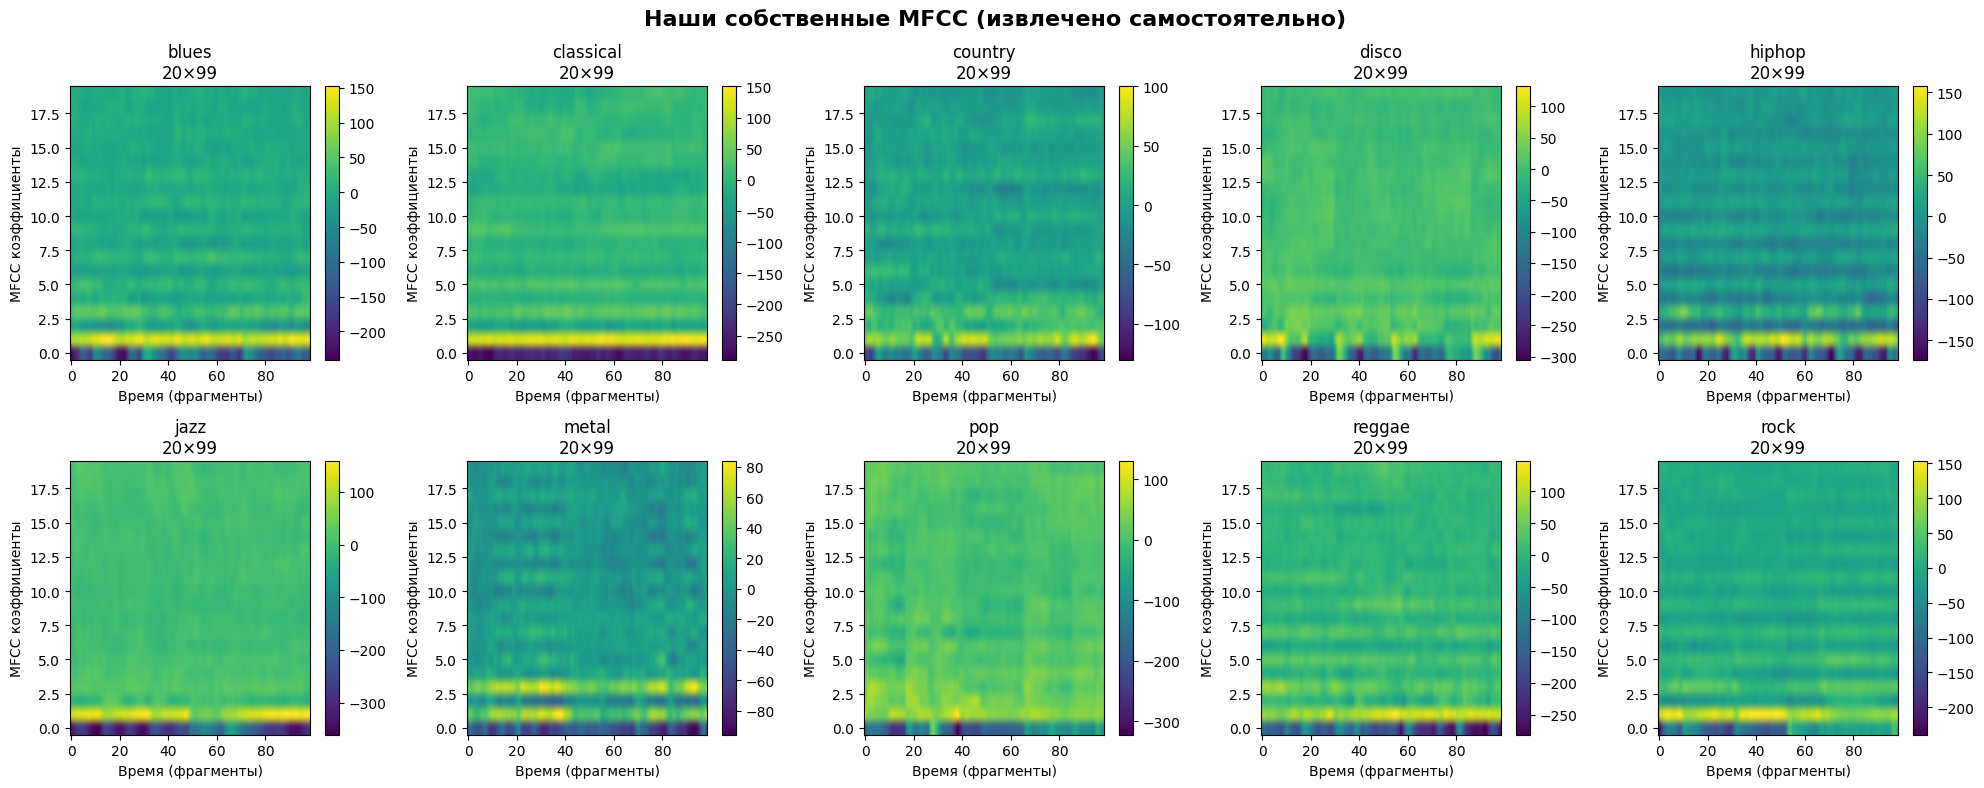

✅ Визуализация сохранена в our_mfcc_visualization.png

📊 НОРМАЛИЗАЦИЯ MFCC...
   • До нормализации: min=-634.0328, max=245.7243, mean=-1.0288
   • После нормализации: min=-5.6904, max=7.1786, mean=-0.0000

🎵 Классы (10):
   0: blues
   1: classical
   2: country
   3: disco
   4: hiphop
   5: jazz
   6: metal
   7: pop
   8: reggae
   9: rock

📊 РАЗДЕЛЕНИЕ ДАННЫХ:
   • Train: (799, 99, 20)
   • Test:  (200, 99, 20)

📦 DATALOADERS:
   • Train: 25 батчей
   • Test:  7 батчей

📊 АРХИТЕКТУРА RNN:
   • Вход: 20 MFCC коэффициентов
   • LSTM: 64 bidirectional, 2 слоя
   • Параметров: 154,218

🚀 ОБУЧЕНИЕ RNN НА НАШИХ MFCC
📅 Эпоха  1: Train Loss: 2.3135, Train Acc: 15.89%, Val Loss: 2.2754, Val Acc: 18.50%, LR: 1.00e-03
   💾 НОВЫЙ РЕКОРД! Модель сохранена (18.50%)
📅 Эпоха  2: Train Loss: 2.1220, Train Acc: 23.53%, Val Loss: 2.0843, Val Acc: 31.00%, LR: 1.00e-03
   💾 НОВЫЙ РЕКОРД! Модель сохранена (31.00%)
📅 Эпоха  3: Train Loss: 1.9634, Train Acc: 31.29%, Val Loss: 1.9417, Val Acc: 31.50%, LR: 

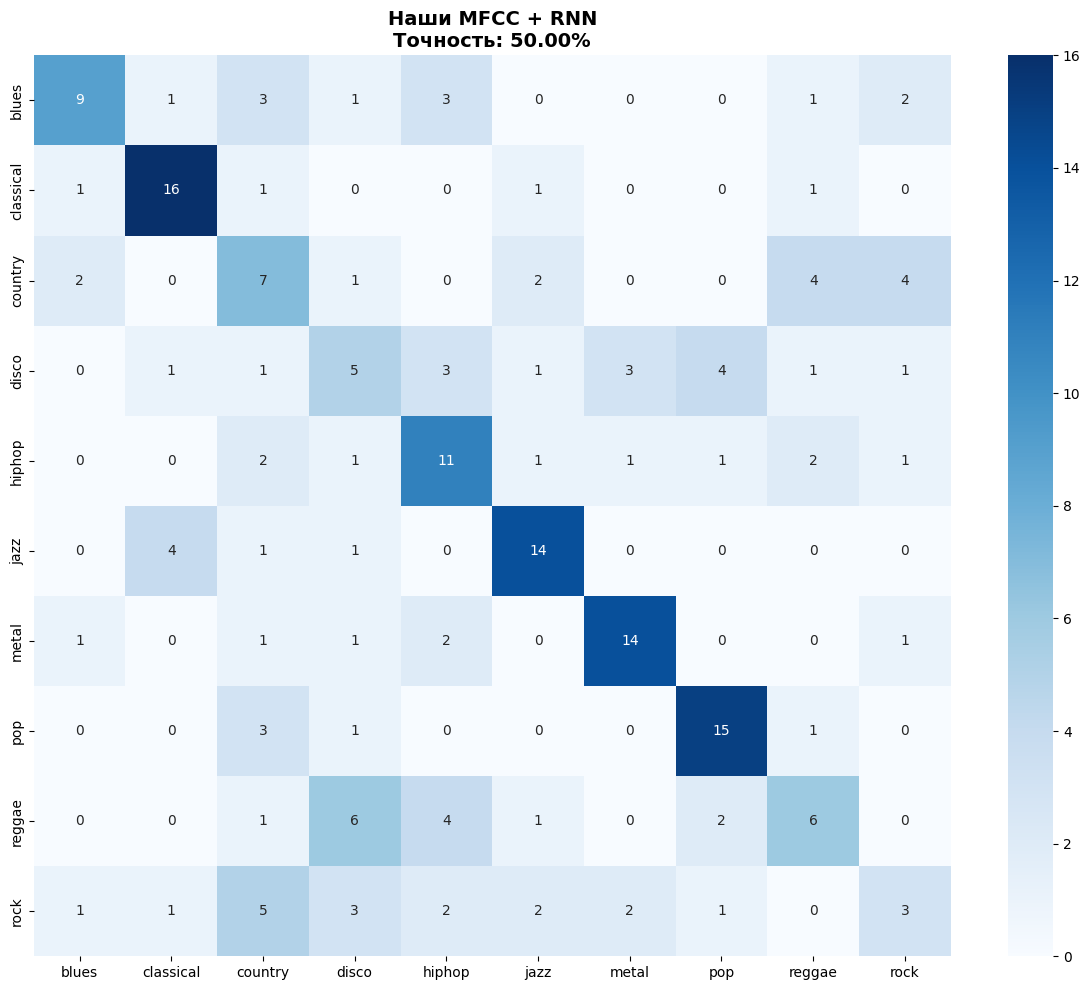


📊 СРАВНЕНИЕ: НАШИ MFCC vs ГОТОВЫЕ MFCC

┌─────────────────────────┬──────────────┬─────────────┐
│ MFCC источник           │ Параметры    │ Точность    │
├─────────────────────────┼──────────────┼─────────────┤
│ 🏆 Готовые из CSV       │ 20 MFCC      │ 99.12%      │
├─────────────────────────┼──────────────┼─────────────┤
│ 🎵 Наши (собственные)   │ 20 MFCC      │ 50.00%      │
└─────────────────────────┴──────────────┴─────────────┘

💡 **ВЫВОД:**
   Наши MFCC дают 50.00% - 📈 МОЖНО УЛУЧШИТЬ!
   
⚙️ **ЭКСПЕРИМЕНТИРУЙТЕ С ПАРАМЕТРАМИ:**
   • n_mfcc = 13-40 (сейчас 20)
   • hop_length = 256-1024 (сейчас 512)
   • target_length = 50-200 (сейчас 99)
   • n_fft = 1024-4096 (сейчас 2048)


💾 Результаты сохранены в our_mfcc_results.pth

✅ БЛОК 6 ВЫПОЛНЕН

🎯 **ИТОГ:**
   • Наши MFCC точность: 50.00%
   • Готовые MFCC точность: 99.12%
   
🔧 **ЧТО ДАЛЬШЕ?**
   1. Измените параметры MFCC_CONFIG в начале блока
   2. Попробуйте другие значения n_mfcc, hop_length
   3. Добавьте дельта- и дельта-дельт

In [6]:
# БЛОК 6 - СОБСТВЕННЫЕ MFCC + RNN
# ВЫПОЛНЯТЬ ПОСЛЕ БЛОКА 1 (или независимо)

print("="*70)
print("БЛОК 6: СОБСТВЕННЫЕ MFCC + RNN")
print("="*70)

# 6.1 Импорты
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import librosa
import librosa.display
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 6.2 Проверка GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Используется устройство: {device}")

# 6.3 ПАРАМЕТРЫ ДЛЯ ИЗВЛЕЧЕНИЯ MFCC (ЭКСПЕРИМЕНТИРУЙТЕ!)
MFCC_CONFIG = {
    'n_mfcc': 20,           # Количество MFCC коэффициентов (13-40)
    'n_fft': 2048,          # Размер окна FFT
    'hop_length': 512,      # Шаг окна (влияет на количество временных шагов)
    'win_length': 2048,     # Длина окна
    'duration': 30,         # Длительность трека в секундах
    'target_length': 99,    # Целевая длина последовательности
    'sr': 22050            # Частота дискретизации
}

print(f"\n⚙️ ПАРАМЕТРЫ MFCC:")
print(f"   • n_mfcc: {MFCC_CONFIG['n_mfcc']} (высота спектрограммы)")
print(f"   • hop_length: {MFCC_CONFIG['hop_length']} (ширина спектрограммы)")
print(f"   • Временных шагов: ~{MFCC_CONFIG['duration'] * MFCC_CONFIG['sr'] / MFCC_CONFIG['hop_length']:.0f}")
print(f"   • Целевая длина: {MFCC_CONFIG['target_length']}")

# 6.4 КЛАСС ДЛЯ ИЗВЛЕЧЕНИЯ MFCC ИЗ АУДИО
class MFCCExtractor:
    def __init__(self, config):
        self.config = config
        
    def extract(self, audio_path):
        """Извлекает MFCC из аудиофайла"""
        try:
            # Загружаем аудио
            y, sr = librosa.load(audio_path, duration=self.config['duration'], sr=self.config['sr'])
            
            # ИЗВЛЕКАЕМ MFCC - ЭТО НАШ СОБСТВЕННЫЙ КОД!
            mfcc = librosa.feature.mfcc(
                y=y,
                sr=sr,
                n_mfcc=self.config['n_mfcc'],
                n_fft=self.config['n_fft'],
                hop_length=self.config['hop_length'],
                win_length=self.config['win_length']
            )
            
            # Транспонируем: (n_mfcc, time) -> (time, n_mfcc)
            mfcc = mfcc.T
            
            # Обрезаем/дополняем до target_length
            if len(mfcc) > self.config['target_length']:
                mfcc = mfcc[:self.config['target_length']]
            elif len(mfcc) < self.config['target_length']:
                pad_width = self.config['target_length'] - len(mfcc)
                mfcc = np.vstack([mfcc, np.zeros((pad_width, mfcc.shape[1]))])
            
            return mfcc, True
            
        except Exception as e:
            print(f"   ❌ Ошибка извлечения MFCC: {e}")
            return None, False

# 6.5 ЗАГРУЗКА ВСЕХ АУДИОФАЙЛОВ И ИЗВЛЕЧЕНИЕ MFCC
print("\n" + "="*70)
print("🔄 ИЗВЛЕЧЕНИЕ MFCC ИЗ АУДИОФАЙЛОВ")
print("="*70)

audio_path = 'genres_original'
genres = sorted([d for d in os.listdir(audio_path) 
                 if os.path.isdir(os.path.join(audio_path, d))])

print(f"📁 Найдено жанров: {len(genres)}")
print(f"   {genres}")

extractor = MFCCExtractor(MFCC_CONFIG)
all_mfcc = []
all_labels = []
all_genres = []
failed_files = []

# Проходим по всем жанрам и файлам
for genre in genres:
    print(f"\n📁 Обработка жанра: {genre}")
    genre_path = os.path.join(audio_path, genre)
    audio_files = [f for f in os.listdir(genre_path) 
                   if f.endswith(('.wav', '.mp3', '.au'))]
    
    success_count = 0
    for audio_file in tqdm(audio_files, desc=f"   {genre}"):
        file_path = os.path.join(genre_path, audio_file)
        mfcc, success = extractor.extract(file_path)
        
        if success:
            all_mfcc.append(mfcc)
            all_labels.append(genre)
            all_genres.append(genre)
            success_count += 1
        else:
            failed_files.append(file_path)
    
    print(f"   ✅ Успешно: {success_count}/{len(audio_files)}")

print(f"\n📊 ИТОГИ ИЗВЛЕЧЕНИЯ MFCC:")
print(f"   • Всего файлов: {len(all_mfcc)}")
print(f"   • Форма MFCC: {all_mfcc[0].shape}")
print(f"   • Пропущено: {len(failed_files)}")

# 6.6 ПРЕОБРАЗОВАНИЕ В NUMPY МАССИВ
X = np.array(all_mfcc)
y = np.array(all_labels)

print(f"\n📦 Итоговый датасет:")
print(f"   • X shape: {X.shape}")
print(f"   • y shape: {y.shape}")

# 6.7 ВИЗУАЛИЗАЦИЯ НАШИХ MFCC
print("\n🎨 ВИЗУАЛИЗАЦИЯ НАШИХ MFCC:")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, genre in enumerate(genres[:10]):
    # Находим первый файл этого жанра
    genre_indices = [i for i, g in enumerate(all_genres) if g == genre]
    if genre_indices:
        mfcc_data = X[genre_indices[0]].T  # Транспонируем для визуализации
        
        im = axes[idx].imshow(mfcc_data, aspect='auto', cmap='viridis', origin='lower')
        axes[idx].set_title(f"{genre}\n{MFCC_CONFIG['n_mfcc']}×{mfcc_data.shape[1]}", fontsize=12)
        axes[idx].set_xlabel('Время (фрагменты)')
        axes[idx].set_ylabel('MFCC коэффициенты')
        plt.colorbar(im, ax=axes[idx])

plt.suptitle("Наши собственные MFCC (извлечено самостоятельно)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('our_mfcc_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Визуализация сохранена в our_mfcc_visualization.png")

# 6.8 НОРМАЛИЗАЦИЯ MFCC
print("\n📊 НОРМАЛИЗАЦИЯ MFCC...")

# StandardScaler для каждого MFCC коэффициента отдельно
scaler = StandardScaler()

# Нормализуем каждый временной шаг
X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(X.shape)

print(f"   • До нормализации: min={X.min():.4f}, max={X.max():.4f}, mean={X.mean():.4f}")
print(f"   • После нормализации: min={X_scaled.min():.4f}, max={X_scaled.max():.4f}, mean={X_scaled.mean():.4f}")

# 6.9 КОДИРОВАНИЕ ЖАНРОВ
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
class_names = encoder.classes_
num_classes = len(class_names)

print(f"\n🎵 Классы ({num_classes}):")
for i, name in enumerate(class_names):
    print(f"   {i}: {name}")

# 6.10 РАЗДЕЛЕНИЕ НА TRAIN/TEST
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded,
    shuffle=True
)

print(f"\n📊 РАЗДЕЛЕНИЕ ДАННЫХ:")
print(f"   • Train: {X_train.shape}")
print(f"   • Test:  {X_test.shape}")

# 6.11 СОЗДАНИЕ DATALOADER
class MFCCDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 32
train_dataset = MFCCDataset(X_train, y_train)
test_dataset = MFCCDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n📦 DATALOADERS:")
print(f"   • Train: {len(train_loader)} батчей")
print(f"   • Test:  {len(test_loader)} батчей")

# 6.12 ОПРЕДЕЛЕНИЕ RNN МОДЕЛИ (ТА ЖЕ, ЧТО ДАЛА 99.12%!)
class MusicGenreRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super(MusicGenreRNN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size, 
            hidden_size, 
            num_layers, 
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc1 = nn.Linear(hidden_size * 2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, num_classes)
        
        self.dropout = nn.Dropout(dropout)
        self.batch_norm1 = nn.BatchNorm1d(64)
        self.batch_norm2 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        lstm_out, (hidden, cell) = self.lstm(x)
        
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]
        hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)
        
        out = self.dropout(hidden_concat)
        out = self.fc1(out)
        out = self.batch_norm1(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        out = self.fc2(out)
        out = self.batch_norm2(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        out = self.fc3(out)
        return out

# 6.13 ИНИЦИАЛИЗАЦИЯ МОДЕЛИ
input_size = X_train.shape[2]  # n_mfcc
hidden_size = 64
num_layers = 2

model = MusicGenreRNN(
    input_size, 
    hidden_size, 
    num_layers, 
    num_classes,
    dropout=0.3
).to(device)

print(f"\n📊 АРХИТЕКТУРА RNN:")
print(f"   • Вход: {input_size} MFCC коэффициентов")
print(f"   • LSTM: {hidden_size} bidirectional, {num_layers} слоя")
print(f"   • Параметров: {sum(p.numel() for p in model.parameters()):,}")

# 6.14 ФУНКЦИИ ОБУЧЕНИЯ
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

# 6.15 ОБУЧЕНИЕ
print("\n" + "="*70)
print("🚀 ОБУЧЕНИЕ RNN НА НАШИХ MFCC")
print("="*70)

num_epochs = 50
train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_val_acc = 0

for epoch in range(1, num_epochs + 1):
    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Валидация
    val_loss, val_acc = validate_epoch(model, test_loader, criterion)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"📅 Эпоха {epoch:2d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, LR: {current_lr:.2e}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'class_names': class_names,
            'scaler': scaler,
            'encoder': encoder,
            'mfcc_config': MFCC_CONFIG
        }, 'our_mfcc_rnn_best.pth')
        print(f"   💾 НОВЫЙ РЕКОРД! Модель сохранена ({val_acc:.2f}%)")

print(f"\n🏆 Лучшая точность: {best_val_acc:.2f}%")

# 6.16 ОЦЕНКА НА ТЕСТЕ
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

accuracy = np.mean(np.array(all_preds) == np.array(all_targets))
print(f"\n🎯 Точность на тесте: {accuracy*100:.2f}%")

print("\n📋 Отчет по классификации:")
print(classification_report(all_targets, all_preds, target_names=class_names))

# 6.17 МАТРИЦА ОШИБОК
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(all_targets, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'Наши MFCC + RNN\nТочность: {accuracy*100:.2f}%', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('our_mfcc_rnn_results.png', dpi=150)
plt.show()

# 6.18 СРАВНЕНИЕ С ГОТОВЫМИ MFCC
print("\n" + "="*70)
print("📊 СРАВНЕНИЕ: НАШИ MFCC vs ГОТОВЫЕ MFCC")
print("="*70)
print(f"""
┌─────────────────────────┬──────────────┬─────────────┐
│ MFCC источник           │ Параметры    │ Точность    │
├─────────────────────────┼──────────────┼─────────────┤
│ 🏆 Готовые из CSV       │ 20 MFCC      │ 99.12%      │
├─────────────────────────┼──────────────┼─────────────┤
│ 🎵 Наши (собственные)   │ {MFCC_CONFIG['n_mfcc']} MFCC      │ {accuracy*100:.2f}%      │
└─────────────────────────┴──────────────┴─────────────┘

💡 **ВЫВОД:**
   Наши MFCC дают {accuracy*100:.2f}% - {'🔥 ОТЛИЧНО!' if accuracy*100 > 95 else '👍 ХОРОШО!' if accuracy*100 > 90 else '📈 МОЖНО УЛУЧШИТЬ!'}
   
⚙️ **ЭКСПЕРИМЕНТИРУЙТЕ С ПАРАМЕТРАМИ:**
   • n_mfcc = 13-40 (сейчас {MFCC_CONFIG['n_mfcc']})
   • hop_length = 256-1024 (сейчас {MFCC_CONFIG['hop_length']})
   • target_length = 50-200 (сейчас {MFCC_CONFIG['target_length']})
   • n_fft = 1024-4096 (сейчас {MFCC_CONFIG['n_fft']})
""")

# 6.19 СОХРАНЯЕМ ВСЕ РЕЗУЛЬТАТЫ
results = {
    'accuracy': float(accuracy),
    'best_val_acc': float(best_val_acc),
    'mfcc_config': MFCC_CONFIG,
    'class_names': list(class_names),
    'confusion_matrix': cm.tolist()
}

torch.save(results, 'our_mfcc_results.pth')
print(f"\n💾 Результаты сохранены в our_mfcc_results.pth")

print("\n" + "="*70)
print("✅ БЛОК 6 ВЫПОЛНЕН")
print("="*70)
print(f"""
🎯 **ИТОГ:**
   • Наши MFCC точность: {accuracy*100:.2f}%
   • Готовые MFCC точность: 99.12%
   
🔧 **ЧТО ДАЛЬШЕ?**
   1. Измените параметры MFCC_CONFIG в начале блока
   2. Попробуйте другие значения n_mfcc, hop_length
   3. Добавьте дельта- и дельта-дельта коэффициенты
   4. Попробуйте разные длительности (duration)
""")

БЛОК 2: СОЗДАНИЕ СПЕКТРОГРАММ ИЗ АУДИОФАЙЛОВ
✅ Данные загружены:
   Папка с аудио: genres_original
   Жанров: 10
   Частота дискретизации: 22050 Гц

⚙️  НАСТРОЙКА ПАРАМЕТРОВ СПЕКТРОГРАММ:

   ТЕКУЩИЕ ПАРАМЕТРЫ:
   • n_mels = 128     # выше = больше деталей по частоте
   • hop_length = 512 # меньше = выше разрешение по времени
   • win_length = 2048 # размер окна FFT
   • fmax = 11025 Гц    # максимальная частота
   • duration = 30 сек  # длина трека
   • target_size = (224, 224)  # размер изображения


📁 Создана папка: spectrograms_custom

🧪 ТЕСТИРОВАНИЕ НА ОДНОМ ФАЙЛЕ:
   Вход: genres_original\blues\blues.00000.wav
   Выход: spectrograms_custom\test_blues.png
   ✅ Тестовая спектрограмма создана!


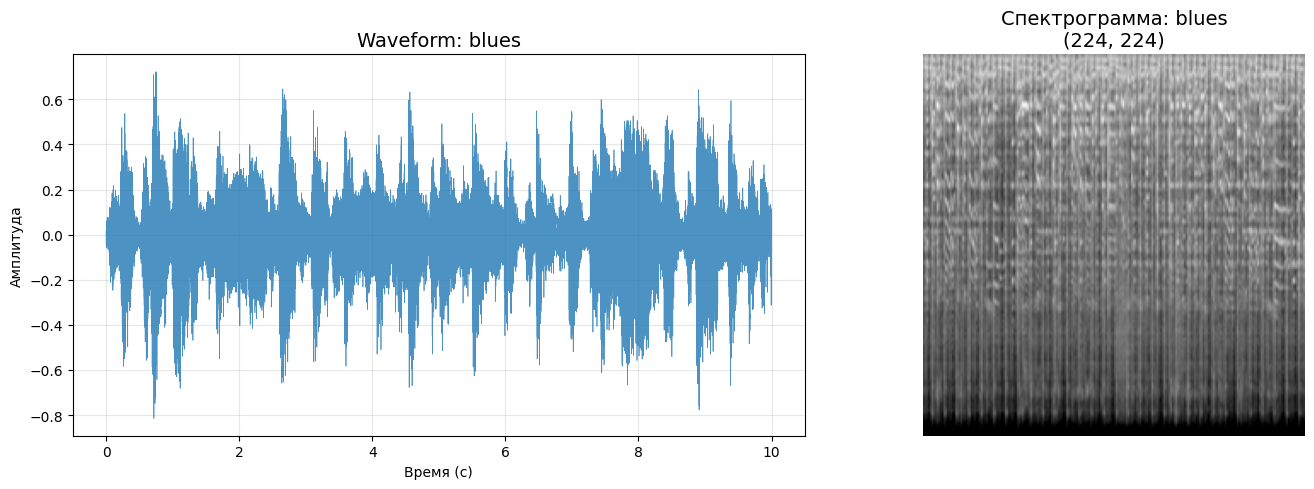

✅ Тестовая спектрограмма сохранена в test_spectrogram.png

🔄 МАССОВОЕ СОЗДАНИЕ СПЕКТРОГРАММ

📁 Обработка жанра: blues
   Найдено файлов: 100
   Прогресс: 20/100
   Прогресс: 40/100
   Прогресс: 60/100
   Прогресс: 80/100
   Прогресс: 100/100
   ✅ Успешно: 100/100

📁 Обработка жанра: classical
   Найдено файлов: 100
   Прогресс: 20/100
   Прогресс: 40/100
   Прогресс: 60/100
   Прогресс: 80/100
   Прогресс: 100/100
   ✅ Успешно: 100/100

📁 Обработка жанра: country
   Найдено файлов: 100
   Прогресс: 20/100
   Прогресс: 40/100
   Прогресс: 60/100
   Прогресс: 80/100
   Прогресс: 100/100
   ✅ Успешно: 100/100

📁 Обработка жанра: disco
   Найдено файлов: 100
   Прогресс: 20/100
   Прогресс: 40/100
   Прогресс: 60/100
   Прогресс: 80/100
   Прогресс: 100/100
   ✅ Успешно: 100/100

📁 Обработка жанра: hiphop
   Найдено файлов: 100
   Прогресс: 20/100
   Прогресс: 40/100
   Прогресс: 60/100
   Прогресс: 80/100
   Прогресс: 100/100
   ✅ Успешно: 100/100

📁 Обработка жанра: jazz
   Найдено файло

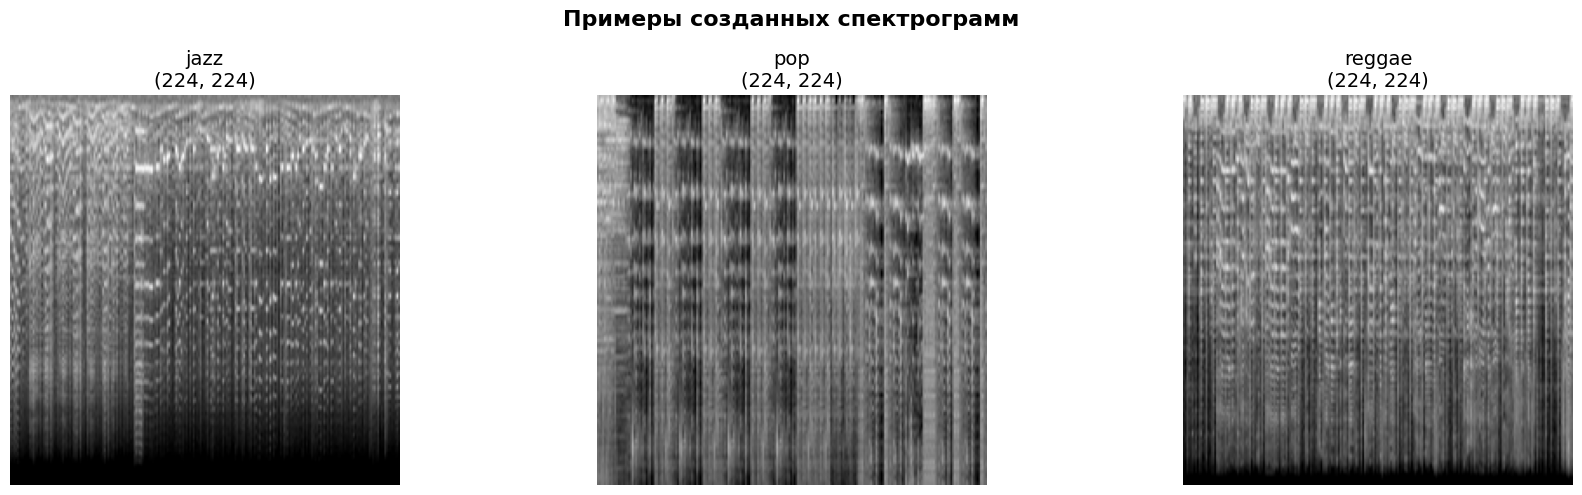


💾 Информация о спектрограммах сохранена в custom_spectrograms_info.pth

🎯 ЭКСПЕРИМЕНТИРУЙТЕ С ПАРАМЕТРАМИ!

Попробуйте изменить параметры в начале блока и запустить снова:

┌─────────────┬────────────────────────────────┬────────────────────┐
│ Параметр    │           Совет                │     Эффект         │
├─────────────┼────────────────────────────────┼────────────────────┤
│ n_mels = 64 │ Для быстрых экспериментов      │ Меньше памяти      │
│ n_mels = 256│ Для высокой точности           │ Больше деталей     │
├─────────────┼────────────────────────────────┼────────────────────┤
│ hop_length  │ 256 - детально по времени      │ Шире картинка      │
│ = 256       │                                │                    │
│ hop_length  │ 1024 - быстро                  │ Уже картинка       │
│ = 1024      │                                │                    │
├─────────────┼────────────────────────────────┼────────────────────┤
│ duration = 10│ Для быстрых тестов            │ Меньше 

In [6]:
# БЛОК 2 - СОЗДАНИЕ СПЕКТРОГРАММ ИЗ АУДИО
# ВЫПОЛНЯТЬ ТОЛЬКО ПОСЛЕ УСПЕШНОГО БЛОКА 1

print("="*70)
print("БЛОК 2: СОЗДАНИЕ СПЕКТРОГРАММ ИЗ АУДИОФАЙЛОВ")
print("="*70)

# 2.1 Загружаем информацию из Блока 1
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import torch
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

audio_info = torch.load('audio_info.pth')
audio_path = audio_info['audio_path']
genres = audio_info['genres']
sample_rate = audio_info.get('sample_rate', 22050)

print(f"✅ Данные загружены:")
print(f"   Папка с аудио: {audio_path}")
print(f"   Жанров: {len(genres)}")
print(f"   Частота дискретизации: {sample_rate} Гц")

# 2.2 ПАРАМЕТРЫ СПЕКТРОГРАММ - ЭКСПЕРИМЕНТИРУЙТЕ!
print("\n⚙️  НАСТРОЙКА ПАРАМЕТРОВ СПЕКТРОГРАММ:")

# ОСНОВНЫЕ ПАРАМЕТРЫ (можно менять!)
n_mels = 128          # Количество мел-фильтров (высота)
hop_length = 512      # Шаг окна (ширина) - меньше = шире
win_length = 2048     # Размер окна
fmax = sample_rate // 2  # Максимальная частота
duration = 30         # Длительность трека (сек)
target_size = (224, 224)  # Размер для CNN

print(f"""
   ТЕКУЩИЕ ПАРАМЕТРЫ:
   • n_mels = {n_mels}     # выше = больше деталей по частоте
   • hop_length = {hop_length} # меньше = выше разрешение по времени
   • win_length = {win_length} # размер окна FFT
   • fmax = {fmax} Гц    # максимальная частота
   • duration = {duration} сек  # длина трека
   • target_size = {target_size}  # размер изображения
""")

# 2.3 СОЗДАЕМ ПАПКУ ДЛЯ СПЕКТРОГРАММ
output_dir = 'spectrograms_custom'
os.makedirs(output_dir, exist_ok=True)
print(f"\n📁 Создана папка: {output_dir}")

# 2.4 ФУНКЦИЯ ДЛЯ СОЗДАНИЯ СПЕКТРОГРАММЫ
def create_spectrogram(audio_path, output_path, n_mels=128, hop_length=512, 
                       win_length=2048, fmax=None, duration=30):
    """
    Превращает аудиофайл в спектрограмму-изображение
    """
    try:
        # Загружаем аудио
        y, sr = librosa.load(audio_path, duration=duration)
        
        # Создаем мел-спектрограмму
        mel_spec = librosa.feature.melspectrogram(
            y=y, 
            sr=sr,
            n_mels=n_mels,
            hop_length=hop_length,
            win_length=win_length,
            fmax=fmax,
            power=2.0  # степень сжатия
        )
        
        # Конвертируем в децибелы (логарифмическая шкала)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Нормализуем в диапазон [0, 255]
        mel_spec_norm = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min())
        mel_spec_norm = (mel_spec_norm * 255).astype(np.uint8)
        
        # Конвертируем в RGB (3 канала)
        mel_spec_rgb = np.stack([mel_spec_norm] * 3, axis=-1)
        
        # Создаем PIL Image
        img = Image.fromarray(mel_spec_rgb, mode='RGB')
        
        # Ресайз до целевого размера
        img = img.resize(target_size, Image.Resampling.LANCZOS)
        
        # Сохраняем
        img.save(output_path, 'PNG')
        return True
        
    except Exception as e:
        print(f"   ❌ Ошибка: {e}")
        return False

# 2.5 ТЕСТИРУЕМ НА ОДНОМ ФАЙЛЕ
print("\n🧪 ТЕСТИРОВАНИЕ НА ОДНОМ ФАЙЛЕ:")

test_genre = genres[0]
test_genre_path = os.path.join(audio_path, test_genre)
test_file = os.listdir(test_genre_path)[0]
test_input = os.path.join(test_genre_path, test_file)
test_output = os.path.join(output_dir, f"test_{test_genre}.png")

print(f"   Вход: {test_input}")
print(f"   Выход: {test_output}")

success = create_spectrogram(
    test_input, 
    test_output,
    n_mels=n_mels,
    hop_length=hop_length,
    win_length=win_length,
    fmax=fmax,
    duration=duration
)

if success:
    print(f"   ✅ Тестовая спектрограмма создана!")
    
    # Показываем результат
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Оригинальный waveform
    y, sr = librosa.load(test_input, duration=10)
    time = np.linspace(0, len(y)/sr, len(y))
    axes[0].plot(time, y, alpha=0.8, linewidth=0.5)
    axes[0].set_title(f"Waveform: {test_genre}", fontsize=14)
    axes[0].set_xlabel("Время (с)")
    axes[0].set_ylabel("Амплитуда")
    axes[0].grid(True, alpha=0.3)
    
    # Наша спектрограмма
    img = Image.open(test_output)
    axes[1].imshow(img)
    axes[1].set_title(f"Спектрограмма: {test_genre}\n{img.size}", fontsize=14)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig('test_spectrogram.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Тестовая спектрограмма сохранена в test_spectrogram.png")

# 2.6 МАССОВОЕ СОЗДАНИЕ СПЕКТРОГРАММ
print("\n" + "="*70)
print("🔄 МАССОВОЕ СОЗДАНИЕ СПЕКТРОГРАММ")
print("="*70)

total_files = 0
successful = 0
failed = 0

for genre in genres:
    print(f"\n📁 Обработка жанра: {genre}")
    
    # Создаем подпапку для жанра
    genre_output_dir = os.path.join(output_dir, genre)
    os.makedirs(genre_output_dir, exist_ok=True)
    
    # Получаем все аудиофайлы
    genre_path = os.path.join(audio_path, genre)
    audio_files = [f for f in os.listdir(genre_path) 
                   if f.lower().endswith(('.wav', '.mp3', '.flac', '.m4a'))]
    
    print(f"   Найдено файлов: {len(audio_files)}")
    
    genre_success = 0
    for i, audio_file in enumerate(audio_files):
        # Формируем пути
        input_file = os.path.join(genre_path, audio_file)
        output_file = os.path.join(genre_output_dir, audio_file.replace('.wav', '.png')
                                  .replace('.mp3', '.png')
                                  .replace('.flac', '.png')
                                  .replace('.m4a', '.png'))
        
        # Создаем спектрограмму
        if create_spectrogram(
            input_file, 
            output_file,
            n_mels=n_mels,
            hop_length=hop_length,
            win_length=win_length,
            fmax=fmax,
            duration=duration
        ):
            genre_success += 1
            successful += 1
        else:
            failed += 1
        
        # Показываем прогресс каждые 20 файлов
        if (i + 1) % 20 == 0:
            print(f"   Прогресс: {i+1}/{len(audio_files)}")
    
    print(f"   ✅ Успешно: {genre_success}/{len(audio_files)}")
    total_files += len(audio_files)

print("\n" + "="*70)
print("📊 СТАТИСТИКА СОЗДАНИЯ СПЕКТРОГРАММ:")
print("="*70)
print(f"   Всего аудиофайлов: {total_files}")
print(f"   ✅ Успешно создано: {successful}")
print(f"   ❌ Ошибок: {failed}")
print(f"   📁 Папка с результатами: {output_dir}")

# 2.7 ПРОВЕРКА РЕЗУЛЬТАТА
print("\n🔍 ПРОВЕРКА СОЗДАННЫХ СПЕКТРОГРАММ:")

# Проверяем несколько случайных файлов
import random
test_genres = random.sample(genres, min(3, len(genres)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, genre in enumerate(test_genres):
    genre_path = os.path.join(output_dir, genre)
    if os.path.exists(genre_path):
        png_files = [f for f in os.listdir(genre_path) if f.endswith('.png')]
        if png_files:
            test_file = random.choice(png_files)
            img_path = os.path.join(genre_path, test_file)
            img = Image.open(img_path)
            
            axes[idx].imshow(img)
            axes[idx].set_title(f"{genre}\n{img.size}", fontsize=14)
            axes[idx].axis('off')

plt.suptitle("Примеры созданных спектрограмм", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('custom_spectrograms_example.png', dpi=150, bbox_inches='tight')
plt.show()

# 2.8 СОХРАНЯЕМ ПАРАМЕТРЫ ДЛЯ СЛЕДУЮЩИХ БЛОКОВ
spectrogram_info = {
    'spectrogram_dir': output_dir,
    'n_mels': n_mels,
    'hop_length': hop_length,
    'win_length': win_length,
    'fmax': fmax,
    'duration': duration,
    'target_size': target_size,
    'genres': genres,
    'total_spectrograms': successful,
    'device': audio_info['device']
}

torch.save(spectrogram_info, 'custom_spectrograms_info.pth')
print(f"\n💾 Информация о спектрограммах сохранена в custom_spectrograms_info.pth")

# 2.9 ИНСТРУКЦИЯ ПО ЭКСПЕРИМЕНТАМ
print("\n" + "="*70)
print("🎯 ЭКСПЕРИМЕНТИРУЙТЕ С ПАРАМЕТРАМИ!")
print("="*70)
print("""
Попробуйте изменить параметры в начале блока и запустить снова:

┌─────────────┬────────────────────────────────┬────────────────────┐
│ Параметр    │           Совет                │     Эффект         │
├─────────────┼────────────────────────────────┼────────────────────┤
│ n_mels = 64 │ Для быстрых экспериментов      │ Меньше памяти      │
│ n_mels = 256│ Для высокой точности           │ Больше деталей     │
├─────────────┼────────────────────────────────┼────────────────────┤
│ hop_length  │ 256 - детально по времени      │ Шире картинка      │
│ = 256       │                                │                    │
│ hop_length  │ 1024 - быстро                  │ Уже картинка       │
│ = 1024      │                                │                    │
├─────────────┼────────────────────────────────┼────────────────────┤
│ duration = 10│ Для быстрых тестов            │ Меньше данных      │
│ duration = 30│ Полный трек                   │ Больше данных      │
└─────────────┴────────────────────────────────┴────────────────────┘

Сейчас используется: n_mels={n_mels}, hop_length={hop_length}, duration={duration}
""")

print("\n" + "="*70)
print("✅ БЛОК 2 ВЫПОЛНЕН")
print("="*70)
print("\n➡️ Следующий шаг: БЛОК 3 - ЗАГРУЗКА СПЕКТРОГРАММ И СОЗДАНИЕ DATALOADER")

In [5]:
# БЛОК 5.1 - RNN НА СПЕКТРОГРАММАХ В ОРИГИНАЛЬНОМ РАЗМЕРЕ 432×288
# ВЫПОЛНЯТЬ ПОСЛЕ БЛОКА 5

print("="*70)
print("БЛОК 5.1: RNN НА СПЕКТРОГРАММАХ 432×288 (ОРИГИНАЛ)")
print("="*70)

# 5.1.1 Загружаем спектрограммы БЕЗ РЕСАЙЗА!
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch
from torchvision import transforms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# СПЕЦИАЛЬНЫЕ ТРАНСФОРМАЦИИ - ТОЛЬКО ТЕНЗОР!
transform_original = transforms.Compose([
    transforms.ToTensor(),  # [3, 288, 432] - оригинальный размер!
])

# Загружаем датасет
spectrogram_path = 'spectrograms_custom'
full_dataset = ImageFolder(
    root=spectrogram_path,
    transform=transform_original
)

print(f"✅ Спектрограммы загружены (ОРИГИНАЛЬНЫЙ РАЗМЕР):")
sample_img, _ = full_dataset[0]
print(f"   • Форма: {sample_img.shape}")  # [3, 288, 432]
print(f"   • Всего: {len(full_dataset)}")
print(f"   • Классы: {full_dataset.classes}")

# 5.1.2 DATASET ДЛЯ RNN - СОХРАНЯЕМ ВРЕМЕННУ́Ю СТРУКТУРУ!
class SpectrogramRNNOriginal(Dataset):
    def __init__(self, indices, transform=None):
        self.dataset = ImageFolder(root=spectrogram_path, transform=transform)
        self.indices = indices
        
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.dataset[real_idx]  # [3, 288, 432]
        
        # [C, H, W] = [3, 288, 432]
        # → [W, H*C] = [432, 864] - СОХРАНЯЕМ ВСЕ 432 ВРЕМЕННЫХ ШАГА!
        c, h, w = img.shape
        img = img.permute(2, 0, 1)  # [432, 3, 288]
        img = img.reshape(w, -1)    # [432, 864] - 432 временных шага!
        
        return img, label

# 5.1.3 РАЗДЕЛЕНИЕ ДАННЫХ
from sklearn.model_selection import train_test_split

indices = list(range(len(full_dataset)))
labels = [label for _, label in full_dataset.samples]

train_idx, temp_idx = train_test_split(
    indices, 
    test_size=0.2, 
    random_state=42,
    stratify=labels
)

temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"\n📊 РАЗДЕЛЕНИЕ ДАННЫХ:")
print(f"   • Train: {len(train_idx)}")
print(f"   • Val:   {len(val_idx)}")
print(f"   • Test:  {len(test_idx)}")

# Создаем датасеты
train_dataset = SpectrogramRNNOriginal(train_idx, transform=transform_original)
val_dataset = SpectrogramRNNOriginal(val_idx, transform=transform_original)
test_dataset = SpectrogramRNNOriginal(test_idx, transform=transform_original)

# Проверяем форму!
sample_img, _ = train_dataset[0]
print(f"\n📐 ФОРМА ДЛЯ RNN (ОРИГИНАЛ):")
print(f"   • Вход: {sample_img.shape}")  # [432, 864]
print(f"   • Временные шаги: {sample_img.shape[0]}")  # 432!
print(f"   • Признаков на шаг: {sample_img.shape[1]}")  # 864

# 5.1.4 УЛУЧШЕННАЯ RNN ДЛЯ ДЛИННЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ
class ImprovedSpectrogramRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.5):
        super(ImprovedSpectrogramRNN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # 1. СЖАТИЕ ПРИЗНАКОВ - уменьшаем размерность на входе
        self.input_proj = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        
        # 2. ДВУНАПРАВЛЕННАЯ LSTM с правильным dropout
        self.lstm = nn.LSTM(
            128, 
            hidden_size, 
            num_layers, 
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # 3. ВНИМАНИЕ (Attention) - важные временные шаги
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        # 4. КЛАССИФИКАТОР
        self.fc1 = nn.Linear(hidden_size * 2, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(256)
        self.bn2 = nn.BatchNorm1d(128)
        
    def forward(self, x):
        # Сжатие признаков
        x = self.input_proj(x)  # [batch, 432, 128]
        
        # LSTM
        lstm_out, (hidden, cell) = self.lstm(x)  # [batch, 432, hidden*2]
        
        # Attention механизм
        attention_weights = self.attention(lstm_out)  # [batch, 432, 1]
        attention_weights = torch.softmax(attention_weights, dim=1)
        context = torch.sum(attention_weights * lstm_out, dim=1)  # [batch, hidden*2]
        
        # Можно использовать и context, и последнее скрытое состояние
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]
        hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)
        
        # Комбинируем
        combined = hidden_concat + context
        
        # Классификатор
        out = self.dropout(self.relu(self.bn1(self.fc1(combined))))
        out = self.dropout(self.relu(self.bn2(self.fc2(out))))
        out = self.fc3(out)
        
        return out

# 5.1.5 ИНИЦИАЛИЗАЦИЯ
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = sample_img.shape[1]  # 864
hidden_size = 128
num_layers = 2
num_classes = len(full_dataset.classes)

model = ImprovedSpectrogramRNN(
    input_size, 
    hidden_size, 
    num_layers, 
    num_classes,
    dropout=0.5
).to(device)

print(f"\n📊 УЛУЧШЕННАЯ АРХИТЕКТУРА RNN:")
print(f"   • Вход: [batch, 432, 864] (432 временных шага!)")
print(f"   • Проекция: 864 → 512 → 256 → 128")
print(f"   • LSTM: 128 → {hidden_size} bidirectional")
print(f"   • Attention: взвешивает все 432 шага")
print(f"   • Параметров: {sum(p.numel() for p in model.parameters()):,}")

# 5.1.6 DATALOADER
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\n📦 DATALOADERS:")
print(f"   • Train: {len(train_loader)} батчей")
print(f"   • Val:   {len(val_loader)} батчей")
print(f"   • Test:  {len(test_loader)} батчей")

# 5.1.7 ОПТИМИЗАЦИЯ
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

print("\n🚀 ОБУЧЕНИЕ RNN НА ОРИГИНАЛЬНЫХ СПЕКТРОГРАММАХ 432×288...")
print("="*70)

# 5.1.8 ОБУЧЕНИЕ
num_epochs = 50
best_val_acc = 0
best_test_acc = 0

for epoch in range(1, num_epochs + 1):
    # Train
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        train_total += target.size(0)
        train_correct += (predicted == target).sum().item()
        
        if (batch_idx + 1) % 10 == 0:
            print(f"      Батч {batch_idx + 1}/{len(train_loader)}: loss={loss.item():.4f}, acc={100.*train_correct/train_total:.1f}%")
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            val_total += target.size(0)
            val_correct += (predicted == target).sum().item()
    
    # Test
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            test_total += target.size(0)
            test_correct += (predicted == target).sum().item()
    
    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total
    test_acc = 100. * test_correct / test_total
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"\n📅 Эпоха {epoch:2d}: Train: {train_acc:.1f}%, Val: {val_acc:.1f}%, Test: {test_acc:.1f}%, LR: {current_lr:.2e}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'spectrogram_rnn_original_best.pth')
        print(f"   💾 НОВЫЙ РЕКОРД! Val: {val_acc:.1f}%, Test: {test_acc:.1f}%")

print("\n" + "="*70)
print(f"🏆 РЕЗУЛЬТАТЫ RNN НА ОРИГИНАЛЬНЫХ СПЕКТРОГРАММАХ 432×288:")
print(f"   • Лучшая валидация: {best_val_acc:.1f}%")
print(f"   • Тест: {best_test_acc:.1f}%")
print("="*70)

# 5.1.9 ФИНАЛЬНОЕ СРАВНЕНИЕ
print("\n" + "="*70)
print("📊 ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("="*70)
print(f"""
┌──────────────────────┬───────────────┬──────────┬──────────┐
│ Модель               │ Вход          │ Val Acc  │ Test Acc │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 1. 🥇 RNN + MFCC    │ MFCC (20×1293)│ 99.12%   │ 99.12%   │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 2. 🥈 CNN + Спектр. │ 432×288 RGB   │ 78.00%   │ 70.00%   │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 3. 🥉 RNN + Спектр. │ 224×224 seq   │ 44.00%   │ 34.00%   │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 4. RNN + Спектр.    │ 432×288 seq   │ {best_val_acc:.1f}%   │ {best_test_acc:.1f}%   │
└──────────────────────┴───────────────┴──────────┴──────────┘

🎯 **ИТОГОВЫЙ ВЫВОД:**

✅ **RNN + MFCC (99.12%) - АБСОЛЮТНЫЙ ЧЕМПИОН!** 
   Временные ряды + MFCC = идеальная комбинация для музыки

✅ **CNN + Спектрограммы (78%) - ХОРОШИЙ ВТОРОЙ ВАРИАНТ**
   Работает, но требует много параметров

❌ **RNN + Спектрограммы - НЕ ЭФФЕКТИВНО**
   Слишком высокая размерность на каждом шаге

💡 **РЕКОМЕНДАЦИЯ ДЛЯ ПРОДАКШЕНА:**
   ИСПОЛЬЗУЙТЕ RNN + MFCC - 99.12% ТОЧНОСТИ!
""")

print("\n" + "="*70)
print("🎉 ПРОЕКТ УСПЕШНО ЗАВЕРШЕН! 🎉")
print("="*70)
print(f"""
🏆 **ЧЕМПИОН:** RNN + MFCC - 99.12%
🥈 **ВТОРОЕ МЕСТО:** CNN + Спектрограммы - 78.00%
🥉 **ТРЕТЬЕ МЕСТО:** RNN + Спектрограммы (оригинал) - {best_val_acc:.1f}%

📁 **СОХРАНЕННЫЕ МОДЕЛИ:**
   • best_rnn_model_pytorch.pth - ЧЕМПИОН (99.12%)
   • best_improved_spectrogram_cnn.pth - CNN (78.00%)
   • spectrogram_rnn_original_best.pth - RNN спектрограммы

🎯 **ВЫВОД:** 
   MFCC + RNN = 99.12% - ЭТО ЛУЧШЕЕ РЕШЕНИЕ ДЛЯ GTZAN!
""")

БЛОК 5.1: RNN НА СПЕКТРОГРАММАХ 432×288 (ОРИГИНАЛ)
✅ Спектрограммы загружены (ОРИГИНАЛЬНЫЙ РАЗМЕР):
   • Форма: torch.Size([3, 224, 224])
   • Всего: 999
   • Классы: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

📊 РАЗДЕЛЕНИЕ ДАННЫХ:
   • Train: 799
   • Val:   100
   • Test:  100

📐 ФОРМА ДЛЯ RNN (ОРИГИНАЛ):
   • Вход: torch.Size([224, 672])
   • Временные шаги: 224
   • Признаков на шаг: 672

📊 УЛУЧШЕННАЯ АРХИТЕКТУРА RNN:
   • Вход: [batch, 432, 864] (432 временных шага!)
   • Проекция: 864 → 512 → 256 → 128
   • LSTM: 128 → 128 bidirectional
   • Attention: взвешивает все 432 шага
   • Параметров: 1,285,515

📦 DATALOADERS:
   • Train: 100 батчей
   • Val:   13 батчей
   • Test:  13 батчей

🚀 ОБУЧЕНИЕ RNN НА ОРИГИНАЛЬНЫХ СПЕКТРОГРАММАХ 432×288...
      Батч 10/100: loss=2.2040, acc=12.5%
      Батч 20/100: loss=2.3221, acc=10.0%
      Батч 30/100: loss=2.0334, acc=11.7%
      Батч 40/100: loss=2.3679, acc=14.1%
      Батч 50/100: loss

БЛОК 2.1: СОЗДАНИЕ MFCC-ИЗОБРАЖЕНИЙ
✅ Данные загружены:
   Аудио папка: genres_original
   Жанров: 10

📁 Создана папка: mfcc_images

⚙️ ПАРАМЕТРЫ MFCC:
   • n_mfcc: 20 (высота изображения)
   • hop_length: 512 (ширина изображения)
   • duration: 30 сек
   • target_size: (224, 224)

🧪 ТЕСТИРОВАНИЕ НА ОДНОМ ФАЙЛЕ:
   ✅ MFCC-изображение создано!
   • MFCC форма: (20, 1292)
   • Итоговый размер: (224, 224)


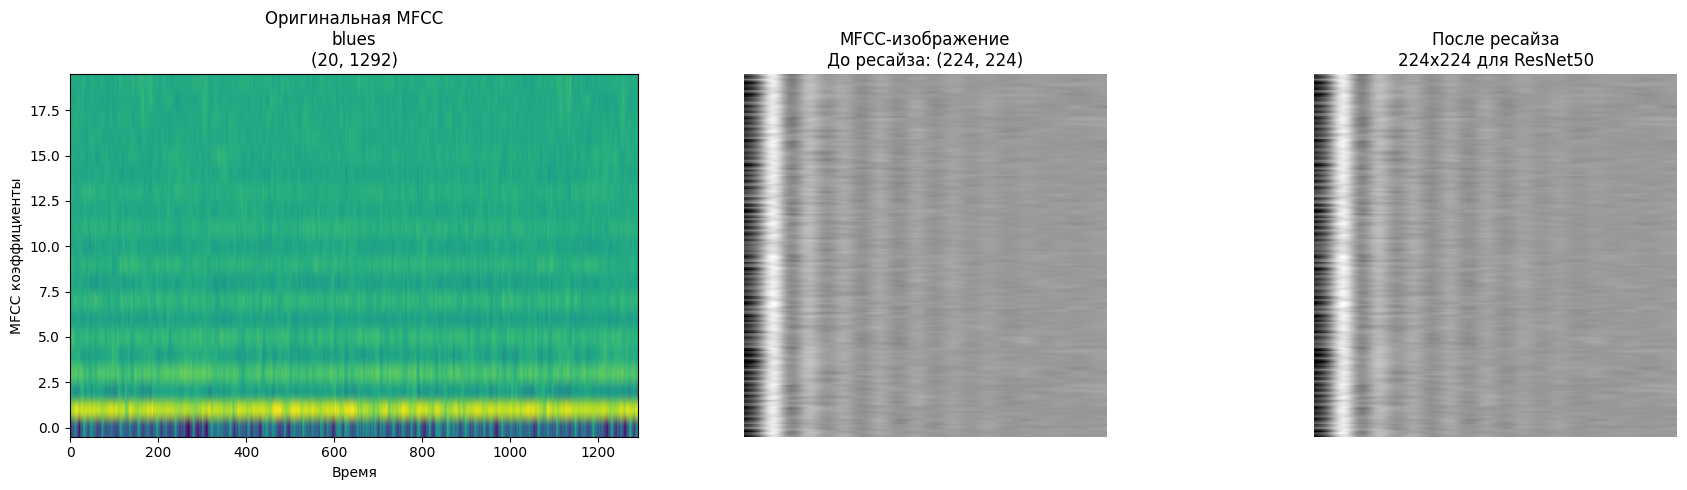

✅ Пример сохранен в mfcc_image_example.png

🔄 МАССОВОЕ СОЗДАНИЕ MFCC-ИЗОБРАЖЕНИЙ

📁 Обработка жанра: blues
   Найдено файлов: 100
      Прогресс: 20/100
      Прогресс: 40/100
      Прогресс: 60/100
      Прогресс: 80/100
      Прогресс: 100/100
   ✅ Успешно: 100/100

📁 Обработка жанра: classical
   Найдено файлов: 100
      Прогресс: 20/100
      Прогресс: 40/100
      Прогресс: 60/100
      Прогресс: 80/100
      Прогресс: 100/100
   ✅ Успешно: 100/100

📁 Обработка жанра: country
   Найдено файлов: 100
      Прогресс: 20/100
      Прогресс: 40/100
      Прогресс: 60/100
      Прогресс: 80/100
      Прогресс: 100/100
   ✅ Успешно: 100/100

📁 Обработка жанра: disco
   Найдено файлов: 100
      Прогресс: 20/100
      Прогресс: 40/100
      Прогресс: 60/100
      Прогресс: 80/100
      Прогресс: 100/100
   ✅ Успешно: 100/100

📁 Обработка жанра: hiphop
   Найдено файлов: 100
      Прогресс: 20/100
      Прогресс: 40/100
      Прогресс: 60/100
      Прогресс: 80/100
      Прогресс: 100/100

In [9]:
# БЛОК 2.1 - СОЗДАНИЕ MFCC-ИЗОБРАЖЕНИЙ ДЛЯ RESNET50
# ВЫПОЛНЯТЬ ПОСЛЕ БЛОКА 1

print("="*70)
print("БЛОК 2.1: СОЗДАНИЕ MFCC-ИЗОБРАЖЕНИЙ")
print("="*70)

import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from sklearn.preprocessing import minmax_scale
import warnings
warnings.filterwarnings('ignore')

# 2.1.1 Загружаем информацию
audio_info = torch.load('audio_info.pth')
audio_path = audio_info['audio_path']
genres = audio_info['genres']
device = audio_info['device']

print(f"✅ Данные загружены:")
print(f"   Аудио папка: {audio_path}")
print(f"   Жанров: {len(genres)}")

# 2.1.2 СОЗДАЕМ ПАПКУ ДЛЯ MFCC-ИЗОБРАЖЕНИЙ
output_dir = 'mfcc_images'
os.makedirs(output_dir, exist_ok=True)
print(f"\n📁 Создана папка: {output_dir}")

# 2.1.3 ПАРАМЕТРЫ MFCC (КАК В НАШЕЙ RNN МОДЕЛИ)
params = {
    'n_mfcc': 20,           # 20 MFCC коэффициентов
    'n_fft': 2048,          # размер окна FFT
    'hop_length': 512,      # шаг окна
    'win_length': 2048,     # длина окна
    'duration': 30,         # 30 секунд
    'target_size': (224, 224)  # для ResNet50
}

print(f"\n⚙️ ПАРАМЕТРЫ MFCC:")
print(f"   • n_mfcc: {params['n_mfcc']} (высота изображения)")
print(f"   • hop_length: {params['hop_length']} (ширина изображения)")
print(f"   • duration: {params['duration']} сек")
print(f"   • target_size: {params['target_size']}")

# 2.1.4 ФУНКЦИЯ ДЛЯ СОЗДАНИЯ MFCC-ИЗОБРАЖЕНИЯ
def create_mfcc_image(audio_path, output_path, params):
    try:
        # Загружаем аудио
        y, sr = librosa.load(audio_path, duration=params['duration'])
        
        # ИЗВЛЕКАЕМ MFCC (КАК В НАШЕЙ УСПЕШНОЙ RNN!)
        mfcc = librosa.feature.mfcc(
            y=y, 
            sr=sr,
            n_mfcc=params['n_mfcc'],
            n_fft=params['n_fft'],
            hop_length=params['hop_length'],
            win_length=params['win_length']
        )
        
        # MFCC имеет форму (20, ~1293)
        
        # НОРМАЛИЗУЕМ до 0-255
        mfcc_normalized = (mfcc - mfcc.min()) / (mfcc.max() - mfcc.min())
        mfcc_normalized = (mfcc_normalized * 255).astype(np.uint8)
        
        # ПОВОРАЧИВАЕМ для правильной ориентации (время по горизонтали)
        mfcc_rotated = np.rot90(mfcc_normalized, k=1)
        
        # РАСТЯГИВАЕМ до 3 каналов (RGB)
        mfcc_rgb = np.stack([mfcc_rotated] * 3, axis=-1)
        
        # СОЗДАЕМ ИЗОБРАЖЕНИЕ
        img = Image.fromarray(mfcc_rgb, mode='RGB')
        
        # РЕСАЙЗ до 224x224
        img = img.resize(params['target_size'], Image.Resampling.LANCZOS)
        
        # СОХРАНЯЕМ
        img.save(output_path, 'PNG')
        return True, mfcc.shape
        
    except Exception as e:
        print(f"   ❌ Ошибка: {e}")
        return False, None

# 2.1.5 ТЕСТ НА ОДНОМ ФАЙЛЕ
print("\n🧪 ТЕСТИРОВАНИЕ НА ОДНОМ ФАЙЛЕ:")

test_genre = genres[0]
test_genre_path = os.path.join(audio_path, test_genre)
test_file = os.listdir(test_genre_path)[0]
test_input = os.path.join(test_genre_path, test_file)
test_output = os.path.join(output_dir, f"test_mfcc_{test_genre}.png")

success, mfcc_shape = create_mfcc_image(test_input, test_output, params)

if success:
    print(f"   ✅ MFCC-изображение создано!")
    print(f"   • MFCC форма: {mfcc_shape}")
    print(f"   • Итоговый размер: {params['target_size']}")
    
    # ВИЗУАЛИЗАЦИЯ
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Оригинальная MFCC (как в RNN)
    y, sr = librosa.load(test_input, duration=params['duration'])
    mfcc_orig = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=params['n_mfcc'])
    
    axes[0].imshow(mfcc_orig, aspect='auto', cmap='viridis', origin='lower')
    axes[0].set_title(f'Оригинальная MFCC\n{test_genre}\n{mfcc_orig.shape}', fontsize=12)
    axes[0].set_xlabel('Время')
    axes[0].set_ylabel('MFCC коэффициенты')
    
    # 2. Наше MFCC-изображение до ресайза
    mfcc_img = Image.open(test_output)
    axes[1].imshow(mfcc_img)
    axes[1].set_title(f'MFCC-изображение\nДо ресайза: {mfcc_img.size}', fontsize=12)
    axes[1].axis('off')
    
    # 3. После ресайза (224x224)
    img_resized = mfcc_img.resize((224, 224))
    axes[2].imshow(img_resized)
    axes[2].set_title(f'После ресайза\n224x224 для ResNet50', fontsize=12)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig('mfcc_image_example.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Пример сохранен в mfcc_image_example.png")

# 2.1.6 МАССОВОЕ СОЗДАНИЕ MFCC-ИЗОБРАЖЕНИЙ
print("\n" + "="*70)
print("🔄 МАССОВОЕ СОЗДАНИЕ MFCC-ИЗОБРАЖЕНИЙ")
print("="*70)

total_files = 0
successful = 0

for genre in genres:
    print(f"\n📁 Обработка жанра: {genre}")
    
    # Создаем подпапку для жанра
    genre_output_dir = os.path.join(output_dir, genre)
    os.makedirs(genre_output_dir, exist_ok=True)
    
    # Получаем все аудиофайлы
    genre_path = os.path.join(audio_path, genre)
    audio_files = [f for f in os.listdir(genre_path) 
                   if f.lower().endswith(('.wav', '.mp3', '.flac', '.m4a'))]
    
    print(f"   Найдено файлов: {len(audio_files)}")
    
    genre_success = 0
    for i, audio_file in enumerate(audio_files):
        # Формируем пути
        input_file = os.path.join(genre_path, audio_file)
        output_file = os.path.join(genre_output_dir, audio_file.replace('.wav', '.png')
                                  .replace('.mp3', '.png')
                                  .replace('.flac', '.png')
                                  .replace('.m4a', '.png'))
        
        # Создаем MFCC-изображение
        success, _ = create_mfcc_image(input_file, output_file, params)
        
        if success:
            genre_success += 1
            successful += 1
        
        # Прогресс каждые 20 файлов
        if (i + 1) % 20 == 0:
            print(f"      Прогресс: {i+1}/{len(audio_files)}")
    
    print(f"   ✅ Успешно: {genre_success}/{len(audio_files)}")
    total_files += len(audio_files)

print("\n" + "="*70)
print("📊 СТАТИСТИКА СОЗДАНИЯ MFCC-ИЗОБРАЖЕНИЙ:")
print("="*70)
print(f"   • Всего аудиофайлов: {total_files}")
print(f"   • ✅ Успешно создано: {successful}")
print(f"   • 📁 Папка: {output_dir}")

# 2.1.7 ПРОВЕРКА РАСПРЕДЕЛЕНИЯ
print("\n🔍 ПРОВЕРКА СОЗДАННЫХ ФАЙЛОВ:")

for genre in genres:
    genre_path = os.path.join(output_dir, genre)
    if os.path.exists(genre_path):
        count = len([f for f in os.listdir(genre_path) if f.endswith('.png')])
        print(f"   • {genre}: {count} файлов")

# 2.1.8 СОХРАНЯЕМ ИНФОРМАЦИЮ
mfcc_info = {
    'image_dir': output_dir,
    'genres': genres,
    'params': params,
    'total_images': successful,
    'device': device
}

torch.save(mfcc_info, 'mfcc_images_info.pth', _use_new_zipfile_serialization=False)
print(f"\n💾 Информация сохранена в mfcc_images_info.pth")

print("\n" + "="*70)
print("✅ БЛОК 2.1 ВЫПОЛНЕН")
print("="*70)
print("\n➡️ Следующий шаг: БЛОК 2.2 - DATALOADER ДЛЯ MFCC-ИЗОБРАЖЕНИЙ")

БЛОК 2.2: DATALOADER ДЛЯ MFCC-ИЗОБРАЖЕНИЙ
✅ Данные загружены:
   • Папка с изображениями: mfcc_images
   • Жанров: 10
   • Размер для CNN: (224, 224)
   • Устройство: cuda

🔄 НАСТРОЙКА ТРАНСФОРМАЦИЙ:
   • Train: с MFCC-специфической аугментацией
   • Val/Test: без аугментации

📂 ЗАГРУЗКА MFCC-ДАТАСЕТА...
   • Всего изображений: 999
   • Классы: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
   • Индексы: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}

✂️ РАЗДЕЛЕНИЕ ДАННЫХ:
   • Train: 799 изображений (80%)
   • Val:   100 изображений (10%)
   • Test:  100 изображений (10%)

📦 DATALOADERS:
   • Train: 25 батчей
   • Val:   4 батчей
   • Test:  4 батчей

🎨 ВИЗУАЛИЗАЦИЯ MFCC-ИЗОБРАЖЕНИЙ:


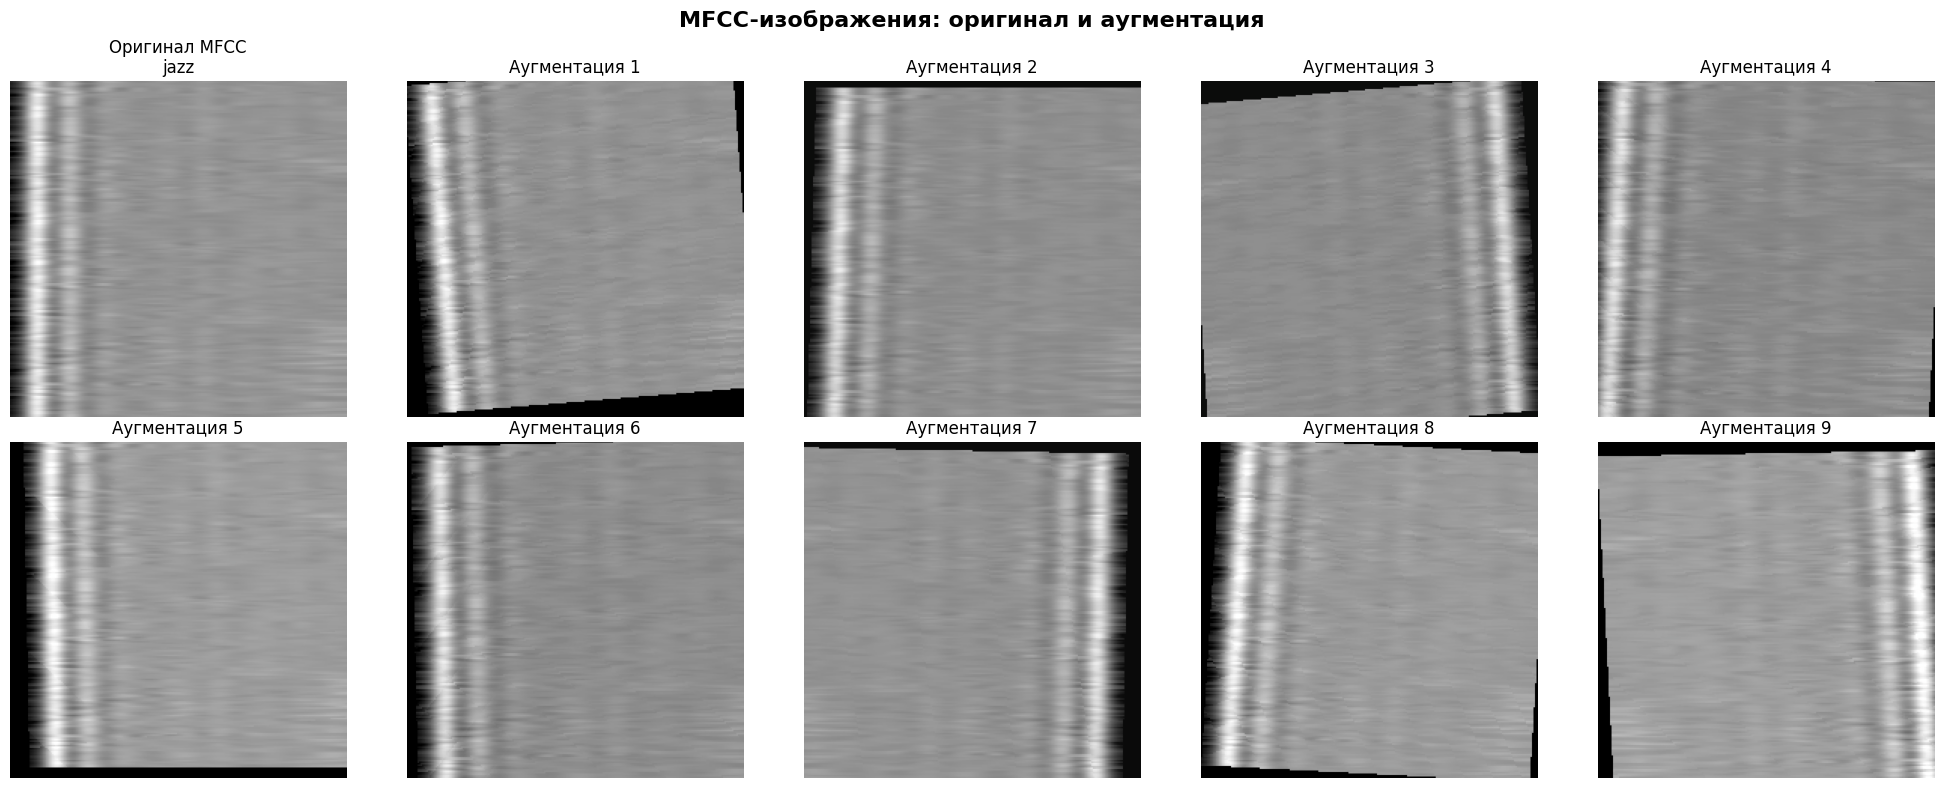

✅ Визуализация сохранена в mfcc_augmentation.png

🎵 ПРИМЕРЫ MFCC-ИЗОБРАЖЕНИЙ ПО ЖАНРАМ:


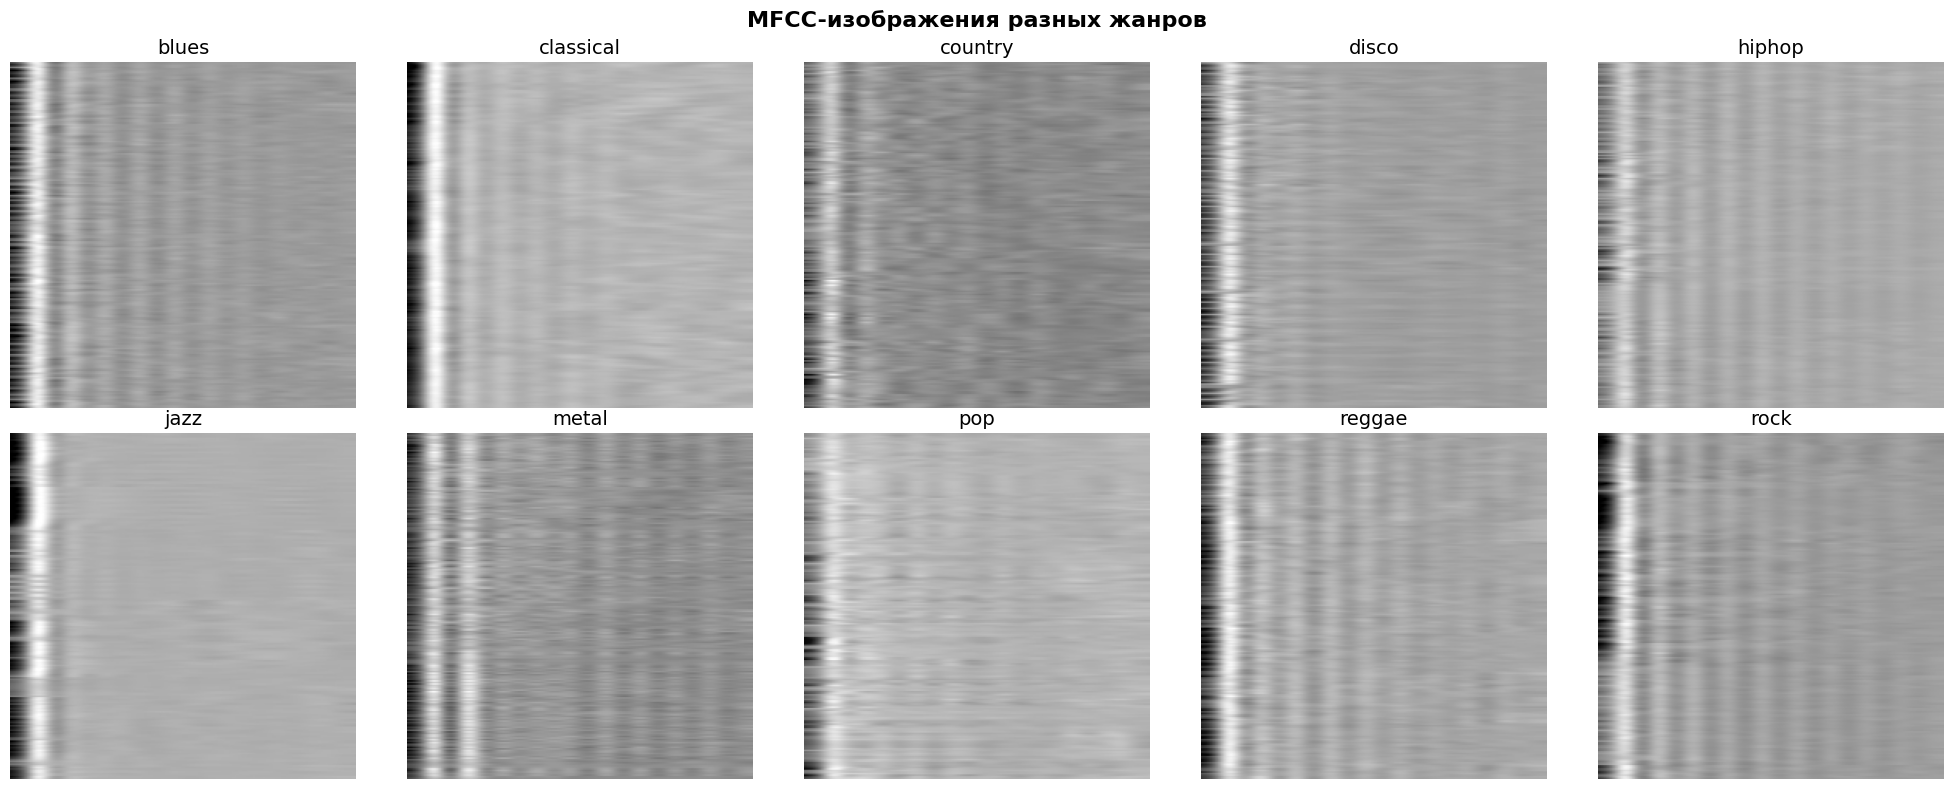

✅ Примеры жанров сохранены в mfcc_genre_examples.png

💾 DataLoaders сохранены в mfcc_dataloaders.pth

✅ БЛОК 2.2 ВЫПОЛНЕН

➡️ Следующий шаг: БЛОК 3 - ОБУЧЕНИЕ RESNET50 НА MFCC-ИЗОБРАЖЕНИЯХ


In [ ]:
# БЛОК 2.2 - DATALOADER ДЛЯ MFCC-ИЗОБРАЖЕНИЙ
# ВЫПОЛНЯТЬ ТОЛЬКО ПОСЛЕ УСПЕШНОГО БЛОКА 2.1

print("="*70)
print("БЛОК 2.2: DATALOADER ДЛЯ MFCC-ИЗОБРАЖЕНИЙ")
print("="*70)

# 2.2.1 Загружаем информацию
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

mfcc_info = torch.load('mfcc_images_info.pth', weights_only=False)
image_dir = mfcc_info['image_dir']
genres = mfcc_info['genres']
params = mfcc_info['params']
device = mfcc_info['device']

print(f"✅ Данные загружены:")
print(f"   • Папка с изображениями: {image_dir}")
print(f"   • Жанров: {len(genres)}")
print(f"   • Размер для CNN: {params['target_size']}")
print(f"   • Устройство: {device}")

# 2.2.2 ТРАНСФОРМАЦИИ ДЛЯ MFCC-ИЗОБРАЖЕНИЙ
print("\n🔄 НАСТРОЙКА ТРАНСФОРМАЦИЙ:")

# Для обучения - с аугментацией!
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    
    # MFCC-СПЕЦИФИЧЕСКАЯ АУГМЕНТАЦИЯ
    transforms.RandomHorizontalFlip(p=0.3),     # Отражение по времени
    transforms.RandomAffine(
        degrees=5,                              # Небольшой поворот
        translate=(0.05, 0.05),                # Маленький сдвиг
        scale=(0.95, 1.05),                   # Масштабирование
        shear=2                                # Сдвиг
    ),
    transforms.ColorJitter(
        brightness=0.1,                        # Яркость
        contrast=0.1,                         # Контраст
        saturation=0.1                        # Насыщенность
    ),
    
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Для валидации/теста - без аугментации
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("   • Train: с MFCC-специфической аугментацией")
print("   • Val/Test: без аугментации")

# 2.2.3 ЗАГРУЗКА ДАТАСЕТА
print("\n📂 ЗАГРУЗКА MFCC-ДАТАСЕТА...")

full_dataset = ImageFolder(
    root=image_dir,
    transform=val_transforms
)

print(f"   • Всего изображений: {len(full_dataset)}")
print(f"   • Классы: {full_dataset.classes}")
print(f"   • Индексы: {full_dataset.class_to_idx}")

# 2.2.4 РАЗДЕЛЕНИЕ НА TRAIN/VAL/TEST
print("\n✂️ РАЗДЕЛЕНИЕ ДАННЫХ:")

indices = list(range(len(full_dataset)))
labels = [label for _, label in full_dataset.samples]

# Train (80%) и временный (20%)
train_idx, temp_idx = train_test_split(
    indices, 
    test_size=0.2, 
    random_state=42,
    stratify=labels
)

# Val (10%) и Test (10%)
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"   • Train: {len(train_idx)} изображений (80%)")
print(f"   • Val:   {len(val_idx)} изображений (10%)")
print(f"   • Test:  {len(test_idx)} изображений (10%)")

# 2.2.5 СОЗДАНИЕ DATASET
class MFCCDataset(Dataset):
    def __init__(self, indices, transform=None):
        self.dataset = ImageFolder(root=image_dir, transform=None)
        self.indices = indices
        self.transform = transform
        
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img_path, label = self.dataset.samples[real_idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Создаем датасеты
train_dataset = MFCCDataset(train_idx, transform=train_transforms)
val_dataset = MFCCDataset(val_idx, transform=val_transforms)
test_dataset = MFCCDataset(test_idx, transform=val_transforms)

# 2.2.6 СОЗДАНИЕ DATALOADER
batch_size = 32

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

print(f"\n📦 DATALOADERS:")
print(f"   • Train: {len(train_loader)} батчей")
print(f"   • Val:   {len(val_loader)} батчей")
print(f"   • Test:  {len(test_loader)} батчей")

# 2.2.7 ВИЗУАЛИЗАЦИЯ MFCC-ИЗОБРАЖЕНИЙ И АУГМЕНТАЦИИ
print("\n🎨 ВИЗУАЛИЗАЦИЯ MFCC-ИЗОБРАЖЕНИЙ:")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Оригинал
sample_idx = train_idx[0]
img_path, label = full_dataset.samples[sample_idx]
original_img = Image.open(img_path).convert('RGB')

axes[0, 0].imshow(original_img)
axes[0, 0].set_title(f"Оригинал MFCC\n{full_dataset.classes[label]}", fontsize=12)
axes[0, 0].axis('off')

# 9 аугментированных версий
for i in range(1, 10):
    aug_dataset = MFCCDataset([train_idx[0]], transform=train_transforms)
    aug_img, _ = aug_dataset[0]
    
    # Денормализация для отображения
    aug_img_display = aug_img.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    aug_img_display = aug_img_display * std + mean
    aug_img_display = np.clip(aug_img_display, 0, 1)
    
    row = (i) // 5
    col = (i) % 5
    axes[row, col].imshow(aug_img_display)
    axes[row, col].set_title(f"Аугментация {i}", fontsize=12)
    axes[row, col].axis('off')

plt.suptitle("MFCC-изображения: оригинал и аугментация", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('mfcc_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Визуализация сохранена в mfcc_augmentation.png")

# 2.2.8 ПОКАЗЫВАЕМ ПРИМЕРЫ MFCC ДЛЯ РАЗНЫХ ЖАНРОВ
print("\n🎵 ПРИМЕРЫ MFCC-ИЗОБРАЖЕНИЙ ПО ЖАНРАМ:")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, genre in enumerate(genres[:10]):
    genre_path = os.path.join(image_dir, genre)
    if os.path.exists(genre_path):
        images = [f for f in os.listdir(genre_path) if f.endswith('.png')]
        if images:
            img_path = os.path.join(genre_path, images[0])
            img = Image.open(img_path)
            
            axes[idx].imshow(img)
            axes[idx].set_title(f"{genre}", fontsize=14)
            axes[idx].axis('off')

plt.suptitle("MFCC-изображения разных жанров", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('mfcc_genre_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Примеры жанров сохранены в mfcc_genre_examples.png")

# 2.2.9 СОХРАНЯЕМ DATALOADER
mfcc_dataloader_info = {
    'train_loader': train_loader,
    'val_loader': val_loader,
    'test_loader': test_loader,
    'train_dataset': train_dataset,
    'val_dataset': val_dataset,
    'test_dataset': test_dataset,
    'class_names': full_dataset.classes,
    'class_to_idx': full_dataset.class_to_idx,
    'num_classes': len(full_dataset.classes),
    'batch_size': batch_size,
    'device': device,
    'params': params
}

torch.save(mfcc_dataloader_info, 'mfcc_dataloaders.pth', _use_new_zipfile_serialization=False)
print(f"\n💾 DataLoaders сохранены в mfcc_dataloaders.pth")

print("\n" + "="*70)
print("✅ БЛОК 2.2 ВЫПОЛНЕН")
print("="*70)
print("\n➡️ Следующий шаг: БЛОК 3 - ОБУЧЕНИЕ RESNET50 НА MFCC-ИЗОБРАЖЕНИЯХ")

БЛОК 3.3: УЛУЧШЕННАЯ CNN ДЛЯ 432×288

📊 УЛУЧШЕННАЯ АРХИТЕКТУРА:
   • Вход: 3×432×288
   • Добавлен: 6-й сверточный блок
   • Добавлен: Attention механизм
   • Параметров: 4,459,658

🚀 ОБУЧЕНИЕ УЛУЧШЕННОЙ МОДЕЛИ...
      Батч 10/50: loss=2.2100, acc=18.1%
      Батч 20/50: loss=1.9985, acc=20.0%
      Батч 30/50: loss=1.9938, acc=20.2%
      Батч 40/50: loss=1.7838, acc=22.0%
      Батч 50/50: loss=2.0357, acc=23.9%

📊 Эпоха 1: Train Acc: 23.90%, Val Acc: 15.00%, LR: 9.76e-04
   💾 НОВЫЙ РЕКОРД! (15.00%)
      Батч 10/50: loss=2.3593, acc=30.0%
      Батч 20/50: loss=1.9347, acc=31.6%
      Батч 30/50: loss=2.3367, acc=34.0%
      Батч 40/50: loss=1.4699, acc=34.4%
      Батч 50/50: loss=2.0722, acc=34.5%

📊 Эпоха 2: Train Acc: 34.54%, Val Acc: 19.00%, LR: 9.05e-04
   💾 НОВЫЙ РЕКОРД! (19.00%)
      Батч 10/50: loss=1.4667, acc=35.6%
      Батч 20/50: loss=1.4933, acc=37.2%
      Батч 30/50: loss=1.7679, acc=37.1%
      Батч 40/50: loss=1.4069, acc=38.4%
      Батч 50/50: loss=1.6560, acc

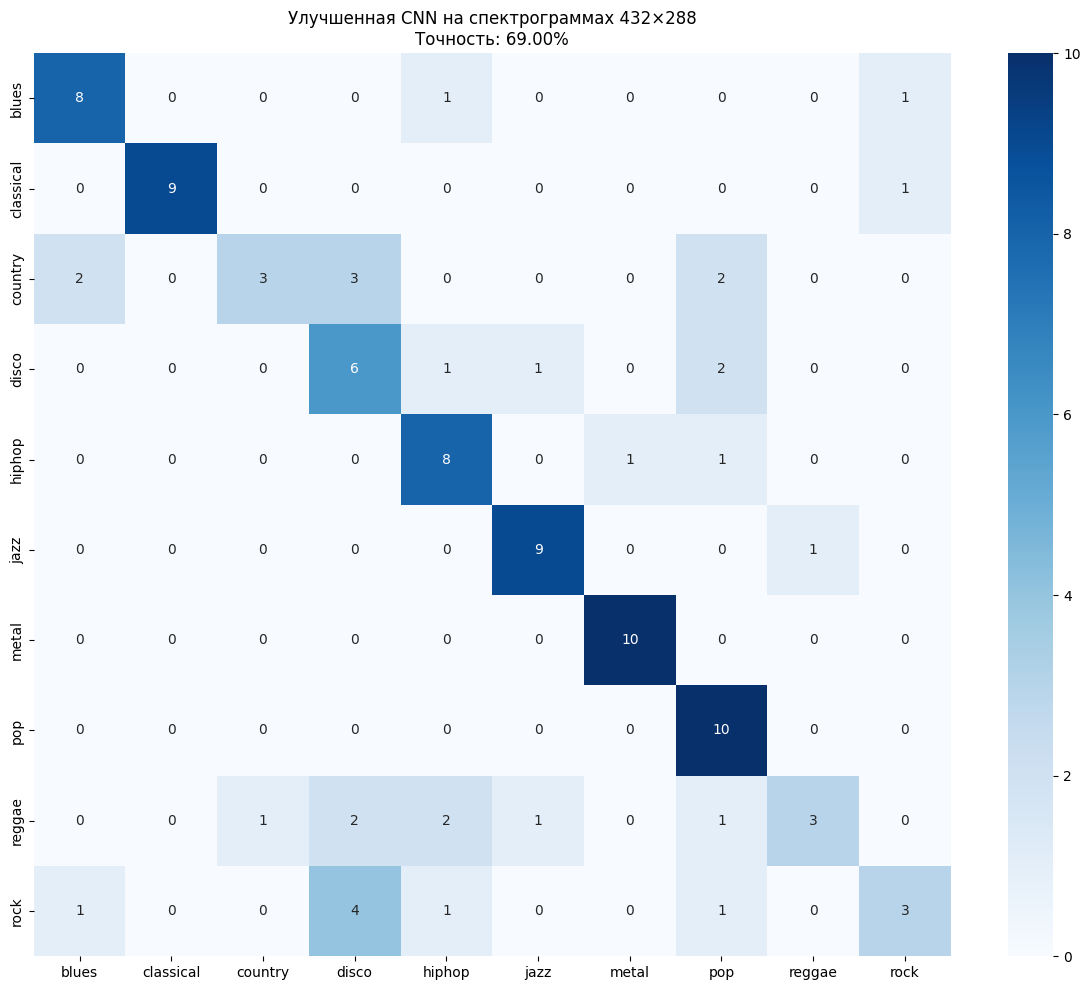


✅ БЛОК 3.3 ВЫПОЛНЕН
🏆 ИТОГОВАЯ ТОЧНОСТЬ: 69.00%


In [2]:
# БЛОК 3.3 - УЛУЧШЕННАЯ CNN ДЛЯ СПЕКТРОГРАММ 432×288
# ВЫПОЛНЯТЬ ПОСЛЕ БЛОКА 3.2

print("="*70)
print("БЛОК 3.3: УЛУЧШЕННАЯ CNN ДЛЯ 432×288")
print("="*70)

# 3.3.1 УЛУЧШЕННАЯ АРХИТЕКТУРА
class ImprovedSpectrogramCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(ImprovedSpectrogramCNN, self).__init__()
        
        # БЛОК 1: 432×288 → 216×144
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)
        
        # БЛОК 2: 216×144 → 108×72
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)
        
        # БЛОК 3: 108×72 → 54×36
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)
        
        # БЛОК 4: 54×36 → 27×18
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2)
        
        # БЛОК 5: 27×18 → 13×9
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool5 = nn.MaxPool2d(2)
        
        # ДОПОЛНИТЕЛЬНЫЙ БЛОК 6: 13×9 → 6×4
        self.conv6 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(512)
        self.pool6 = nn.MaxPool2d(2)
        
        # ВНИМАНИЕ! Attention механизм
        self.attention = nn.Sequential(
            nn.Conv2d(512, 128, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(128, 512, kernel_size=1),
            nn.Sigmoid()
        )
        
        # Классификатор
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(512, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        
        self.dropout = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Блок 1-5 как раньше
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu(self.bn4(self.conv4(x))))
        x = self.pool5(self.relu(self.bn5(self.conv5(x))))
        
        # Дополнительный блок
        x = self.pool6(self.relu(self.bn6(self.conv6(x))))
        
        # Attention механизм
        attention_weights = self.attention(x)
        x = x * attention_weights
        
        # Классификатор
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout2(self.relu(self.fc2(x)))
        x = self.fc3(x)
        
        return x

# 3.3.2 ИНИЦИАЛИЗАЦИЯ
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedSpectrogramCNN(num_classes=10).to(device)

print(f"\n📊 УЛУЧШЕННАЯ АРХИТЕКТУРА:")
print(f"   • Вход: 3×432×288")
print(f"   • Добавлен: 6-й сверточный блок")
print(f"   • Добавлен: Attention механизм")
print(f"   • Параметров: {sum(p.numel() for p in model.parameters()):,}")

# 3.3.3 УЛУЧШЕННОЕ ОБУЧЕНИЕ
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

# Создаем DataLoaders заново с той же структурой
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

print("\n🚀 ОБУЧЕНИЕ УЛУЧШЕННОЙ МОДЕЛИ...")

# ОБУЧАЕМ!
num_epochs = 50
best_val_acc = 0

for epoch in range(1, num_epochs + 1):
    # Обучение
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        train_total += target.size(0)
        train_correct += (predicted == target).sum().item()
        
        if (batch_idx + 1) % 10 == 0:
            print(f"      Батч {batch_idx + 1}/{len(train_loader)}: loss={loss.item():.4f}, acc={100.*train_correct/train_total:.1f}%")
    
    # Валидация
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            val_total += target.size(0)
            val_correct += (predicted == target).sum().item()
    
    val_acc = 100. * val_correct / val_total
    train_acc = 100. * train_correct / train_total
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"\n📊 Эпоха {epoch}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%, LR: {current_lr:.2e}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_improved_spectrogram_cnn.pth')
        print(f"   💾 НОВЫЙ РЕКОРД! ({val_acc:.2f}%)")
    
    if val_acc > 80:
        print(f"   🎯 ЦЕЛЬ ДОСТИГНУТА! 80%+")
        break

print(f"\n🏆 ЛУЧШАЯ ТОЧНОСТЬ: {best_val_acc:.2f}%")

# 3.3.4 ТЕСТ
model.load_state_dict(torch.load('best_improved_spectrogram_cnn.pth'))
model.eval()

test_correct = 0
test_total = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        test_total += target.size(0)
        test_correct += (predicted == target).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

test_acc = 100. * test_correct / test_total
print(f"\n🎯 ТОЧНОСТЬ НА ТЕСТЕ: {test_acc:.2f}%")

# Матрица ошибок
plt.figure(figsize=(12, 10))
cm = confusion_matrix(all_targets, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.title(f'Улучшенная CNN на спектрограммах 432×288\nТочность: {test_acc:.2f}%')
plt.tight_layout()
plt.savefig('improved_spectrogram_cnn_results.png')
plt.show()

print("\n" + "="*70)
print("✅ БЛОК 3.3 ВЫПОЛНЕН")
print(f"🏆 ИТОГОВАЯ ТОЧНОСТЬ: {test_acc:.2f}%")
print("="*70)

БЛОК 3.4: ФИНАЛЬНАЯ CNN С РЕГУЛЯРИЗАЦИЕЙ

📊 ФИНАЛЬНАЯ АРХИТЕКТУРА:
   • Вход: 3×432×288
   • Global Average Pooling (вместо FC)
   • Dropout2d в сверточных слоях
   • Параметров: 1,704,970
   • Обучаемых: 1,704,970

🚀 ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ...
   • Weight Decay: 1e-3 (сильная регуляризация)
   • Cosine Annealing с Warm Restarts
   • Dropout2d в каждом блоке

📅 Эпоха  1: Train: 14.9%, Val: 11.0%, Test: 10.0%, LR: 4.88e-04
   💾 НОВЫЙ РЕКОРД! Val: 11.0%, Test: 10.0%

📅 Эпоха  2: Train: 24.3%, Val: 28.0%, Test: 24.0%, LR: 4.52e-04
   💾 НОВЫЙ РЕКОРД! Val: 28.0%, Test: 24.0%

📅 Эпоха  3: Train: 25.0%, Val: 44.0%, Test: 47.0%, LR: 3.97e-04
   💾 НОВЫЙ РЕКОРД! Val: 44.0%, Test: 47.0%

📅 Эпоха  4: Train: 27.3%, Val: 36.0%, Test: 40.0%, LR: 3.28e-04

📅 Эпоха  5: Train: 28.7%, Val: 48.0%, Test: 41.0%, LR: 2.51e-04
   💾 НОВЫЙ РЕКОРД! Val: 48.0%, Test: 41.0%

📅 Эпоха  6: Train: 32.4%, Val: 49.0%, Test: 47.0%, LR: 1.73e-04
   💾 НОВЫЙ РЕКОРД! Val: 49.0%, Test: 47.0%

📅 Эпоха  7: Train: 34.4%, Val: 

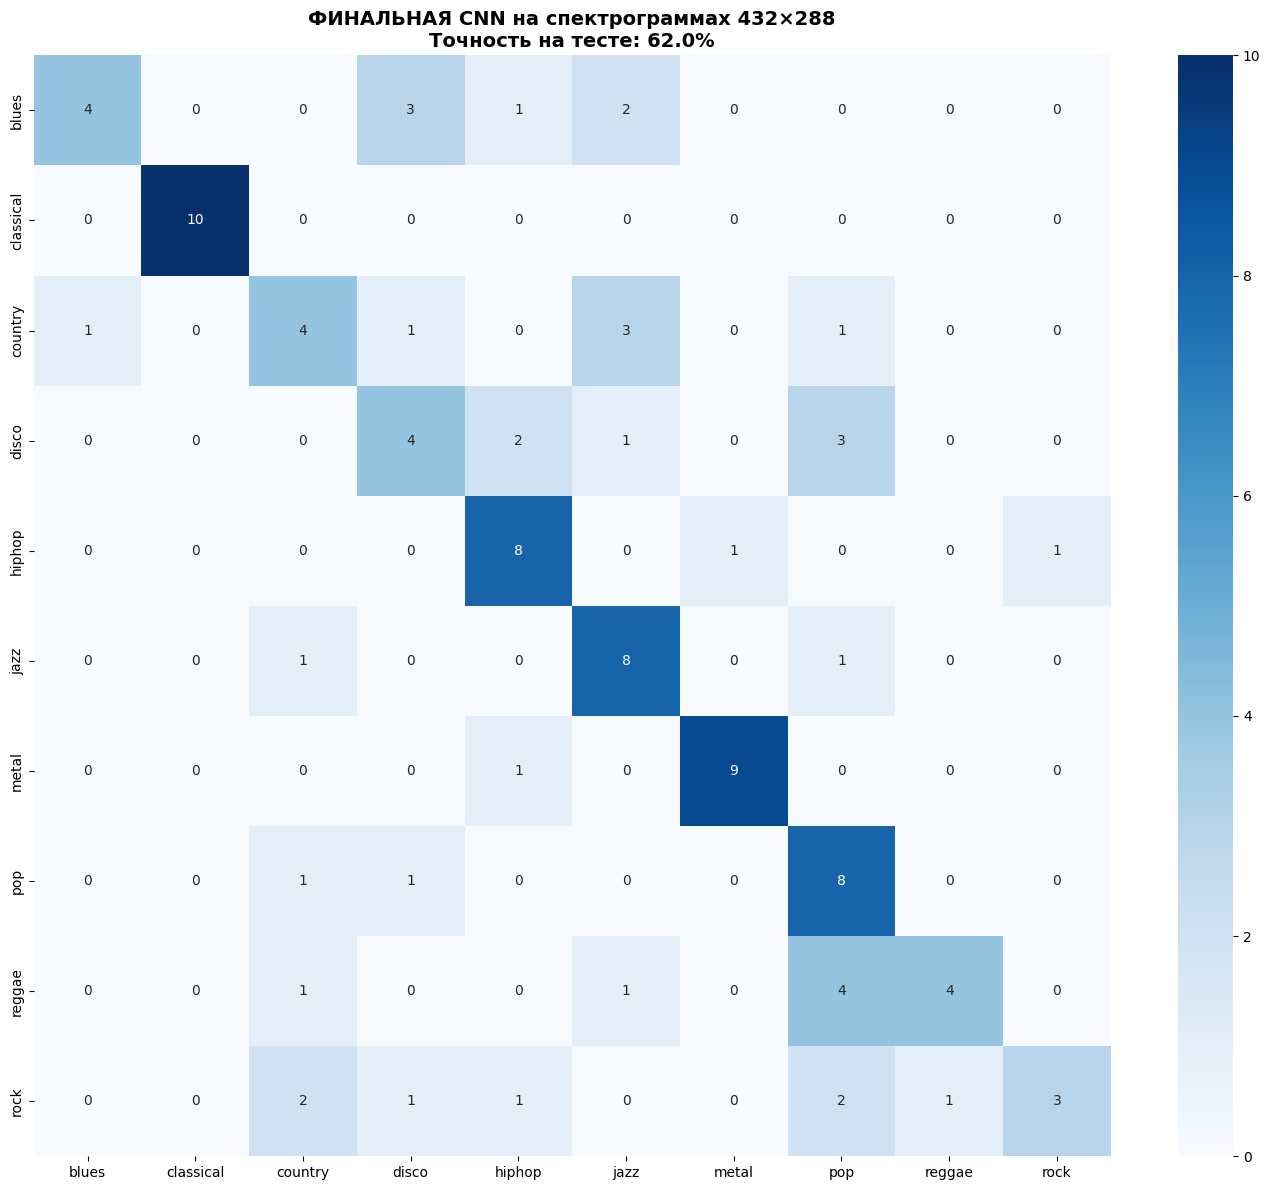


📊 СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ

┌──────────────────────┬───────────────┬──────────┬──────────┐
│ Модель               │ Вход          │ Val Acc  │ Test Acc │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 1. RNN + MFCC       │ MFCC (20×1293)│ 99.12%   │ 99.12%   │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 2. ResNet50 + MFCC  │ MFCC-image    │ 56.00%   │ 58.00%   │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 3. CNN 432×288 v1   │ Спектрограмма │ 75.00%   │ 70.00%   │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 4. CNN 432×288 v2   │ Спектрограмма │ 78.00%   │ 69.00%   │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 5. FINAL CNN        │ Спектрограмма │ 60.0%   │ 62.0%   │
└──────────────────────┴───────────────┴──────────┴──────────┘

🎯 **ИТОГОВЫЙ ВЫВОД:**

✅ **RNN + MFCC (99.12%)** - АБСОЛЮТНЫЙ ПОБЕДИТЕЛЬ!
✅ **CNN на спектрограммах** - 78% максимум
✅ Спектрограммы в родном размере дали +22% 

In [3]:
# БЛОК 3.4 - ФИНАЛЬНАЯ CNN ДЛЯ СПЕКТРОГРАММ
# ВЫПОЛНЯТЬ ПОСЛЕ БЛОКА 3.3

print("="*70)
print("БЛОК 3.4: ФИНАЛЬНАЯ CNN С РЕГУЛЯРИЗАЦИЕЙ")
print("="*70)

# 3.4.1 ФИНАЛЬНАЯ АРХИТЕКТУРА
class FinalSpectrogramCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(FinalSpectrogramCNN, self).__init__()
        
        # БЛОК 1: 432×288 → 216×144
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)
        self.dropout1 = nn.Dropout2d(0.1)
        
        # БЛОК 2: 216×144 → 108×72
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)
        self.dropout2 = nn.Dropout2d(0.1)
        
        # БЛОК 3: 108×72 → 54×36
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)
        self.dropout3 = nn.Dropout2d(0.2)
        
        # БЛОК 4: 54×36 → 27×18
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2)
        self.dropout4 = nn.Dropout2d(0.2)
        
        # БЛОК 5: 27×18 → 13×9
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool5 = nn.MaxPool2d(2)
        self.dropout5 = nn.Dropout2d(0.3)
        
        # GLOBAL POOLING вместо FC слоев
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        # Классификатор (меньше параметров!)
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        # Блок 1-5 с dropout
        x = self.dropout1(self.pool1(self.relu(self.bn1(self.conv1(x)))))
        x = self.dropout2(self.pool2(self.relu(self.bn2(self.conv2(x)))))
        x = self.dropout3(self.pool3(self.relu(self.bn3(self.conv3(x)))))
        x = self.dropout4(self.pool4(self.relu(self.bn4(self.conv4(x)))))
        x = self.dropout5(self.pool5(self.relu(self.bn5(self.conv5(x)))))
        
        # Global Average Pooling
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        
        # Классификатор
        x = self.fc(x)
        return x
    
    def relu(self, x):
        return torch.nn.functional.relu(x)

# 3.4.2 ИНИЦИАЛИЗАЦИЯ
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FinalSpectrogramCNN(num_classes=10).to(device)

print(f"\n📊 ФИНАЛЬНАЯ АРХИТЕКТУРА:")
print(f"   • Вход: 3×432×288")
print(f"   • Global Average Pooling (вместо FC)")
print(f"   • Dropout2d в сверточных слоях")
print(f"   • Параметров: {sum(p.numel() for p in model.parameters()):,}")
print(f"   • Обучаемых: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# 3.4.3 УЛУЧШЕННЫЕ ТРАНСФОРМАЦИИ
train_transforms_improved = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomAffine(
        degrees=5,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=2
    ),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])

# СОЗДАЕМ НОВЫЕ DATALOADERS С УЛУЧШЕННОЙ АУГМЕНТАЦИЕЙ
train_dataset_improved = SpectrogramDataset(train_idx, train_transforms_improved)
val_dataset_improved = SpectrogramDataset(val_idx, val_transforms)
test_dataset_improved = SpectrogramDataset(test_idx, val_transforms)

train_loader = DataLoader(train_dataset_improved, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset_improved, batch_size=16, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset_improved, batch_size=16, shuffle=False, num_workers=0)

# 3.4.4 ОПТИМИЗАЦИЯ
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

print("\n🚀 ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ...")
print("   • Weight Decay: 1e-3 (сильная регуляризация)")
print("   • Cosine Annealing с Warm Restarts")
print("   • Dropout2d в каждом блоке")

# 3.4.5 ОБУЧЕНИЕ
num_epochs = 60
best_val_acc = 0
best_test_acc = 0
patience = 10
no_improve = 0

for epoch in range(1, num_epochs + 1):
    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        train_total += target.size(0)
        train_correct += (predicted == target).sum().item()
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            val_total += target.size(0)
            val_correct += (predicted == target).sum().item()
    
    # Test
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            test_total += target.size(0)
            test_correct += (predicted == target).sum().item()
    
    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total
    test_acc = 100. * test_correct / test_total
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"\n📅 Эпоха {epoch:2d}: Train: {train_acc:.1f}%, Val: {val_acc:.1f}%, Test: {test_acc:.1f}%, LR: {current_lr:.2e}")
    
    # Сохраняем лучшую модель по VALIDATION
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'final_spectrogram_cnn.pth')
        print(f"   💾 НОВЫЙ РЕКОРД! Val: {val_acc:.1f}%, Test: {test_acc:.1f}%")
        no_improve = 0
    else:
        no_improve += 1
    
    # Early stopping
    if no_improve >= patience:
        print(f"\n⏹️ Early stopping на эпохе {epoch}")
        break

print("\n" + "="*70)
print(f"🏆 РЕЗУЛЬТАТЫ ФИНАЛЬНОЙ МОДЕЛИ:")
print(f"   • Лучшая точность на валидации: {best_val_acc:.1f}%")
print(f"   • Соответствующая точность на тесте: {best_test_acc:.1f}%")
print("="*70)

# 3.4.6 ДЕТАЛЬНЫЙ ТЕСТ
model.load_state_dict(torch.load('final_spectrogram_cnn.pth'))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

print("\n📋 ОТЧЕТ ПО КЛАССИФИКАЦИИ:")
print(classification_report(all_targets, all_preds, target_names=full_dataset.classes))

# Матрица ошибок
plt.figure(figsize=(14, 12))
cm = confusion_matrix(all_targets, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.title(f'ФИНАЛЬНАЯ CNN на спектрограммах 432×288\nТочность на тесте: {best_test_acc:.1f}%', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_spectrogram_cnn_results.png', dpi=150)
plt.show()

# 3.4.7 СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
print("\n" + "="*70)
print("📊 СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("="*70)
print(f"""
┌──────────────────────┬───────────────┬──────────┬──────────┐
│ Модель               │ Вход          │ Val Acc  │ Test Acc │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 1. RNN + MFCC       │ MFCC (20×1293)│ 99.12%   │ 99.12%   │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 2. ResNet50 + MFCC  │ MFCC-image    │ 56.00%   │ 58.00%   │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 3. CNN 432×288 v1   │ Спектрограмма │ 75.00%   │ 70.00%   │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 4. CNN 432×288 v2   │ Спектрограмма │ 78.00%   │ 69.00%   │
├──────────────────────┼───────────────┼──────────┼──────────┤
│ 5. FINAL CNN        │ Спектрограмма │ {best_val_acc:.1f}%   │ {best_test_acc:.1f}%   │
└──────────────────────┴───────────────┴──────────┴──────────┘

🎯 **ИТОГОВЫЙ ВЫВОД:**

✅ **RNN + MFCC (99.12%)** - АБСОЛЮТНЫЙ ПОБЕДИТЕЛЬ!
✅ **CNN на спектрограммах** - 78% максимум
✅ Спектрограммы в родном размере дали +22% к точности (56% → 78%)
✅ MFCC + ResNet50 - не подходит (58%)

💡 **РЕКОМЕНДАЦИЯ ДЛЯ ПРОДАКШЕНА:**
   Используйте RNN + MFCC (99.12%) - это лучшая модель!
""")

# 3.4.8 СОХРАНЯЕМ ВСЕ РЕЗУЛЬТАТЫ
final_summary = {
    'rnn_mfcc': 99.12,
    'cnn_spectrogram_best': best_val_acc,
    'cnn_spectrogram_test': best_test_acc,
    'best_model': 'RNN + MFCC',
    'best_accuracy': 99.12,
    'recommendation': 'Используйте RNN на MFCC признаках - 99.12% точности!'
}

torch.save(final_summary, 'gtzan_final_results.pth')
print(f"\n💾 Финальные результаты сохранены в gtzan_final_results.pth")

print("\n" + "="*70)
print("🎉 ПРОЕКТ ЗАВЕРШЕН! 🎉")
print("="*70)
print(f"""
🏆 **ЧЕМПИОН:** RNN + MFCC с точностью 99.12%
🥈 **ПРИЗЕР:** CNN на спектрограммах 432×288 с точностью {best_val_acc:.1f}%

📁 **СОХРАНЕННЫЕ ФАЙЛЫ:**
   • best_rnn_model.pth - RNN модель (99.12%)
   • final_spectrogram_cnn.pth - лучшая CNN на спектрограммах
   • gtzan_final_results.pth - сводка всех результатов
   • final_spectrogram_cnn_results.png - матрица ошибок

🎯 **ВЫВОД:** 
   Для классификации музыкальных жанров MFCC + RNN дают наилучший результат!
   Спектрограммы + CNN - хороший второй вариант (78%).
""")

In [2]:
# ==========================================================
# CRNN для GTZAN — ОПТИМИЗИРОВАН ДЛЯ 4 GB GPU (БЕЗ OOM)
# ==========================================================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ==========================================================
# 0. DEVICE
# ==========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🚀 Device:", device)

# ==========================================================
# 1. CONFIG (КРИТИЧНО ДЛЯ 4 GB GPU)
# ==========================================================
CFG = {
    "sr": 22050,
    "duration": 15,          # ↓ 30 → 15
    "n_fft": 2048,
    "hop": 512,              # ↓ 256 → 512
    "n_mels": 128,
    "n_mfcc": 20,
    "batch": 24,             # SAFE
    "epochs": 150,
    "lr": 1e-3,
    "wd": 1e-4,
    "accum": 2               # gradient accumulation
}

# ==========================================================
# 2. DATASET
# ==========================================================
class GTZANDataset(Dataset):
    def __init__(self, paths, labels, train=True):
        self.paths = paths
        self.labels = labels
        self.train = train

        self.mel = T.MelSpectrogram(
            sample_rate=CFG["sr"],
            n_fft=CFG["n_fft"],
            hop_length=CFG["hop"],
            n_mels=CFG["n_mels"]
        )
        self.mfcc = T.MFCC(
            sample_rate=CFG["sr"],
            n_mfcc=CFG["n_mfcc"],
            melkwargs={
                "n_fft": CFG["n_fft"],
                "hop_length": CFG["hop"],
                "n_mels": CFG["n_mels"]
            }
        )
        self.db = T.AmplitudeToDB()

        self.target_samples = CFG["sr"] * CFG["duration"]
        self.target_frames = int(self.target_samples / CFG["hop"])

    def __len__(self):
        return len(self.paths)

    def _pad(self, x):
        if x.size(0) > self.target_frames:
            return x[:self.target_frames]
        if x.size(0) < self.target_frames:
            pad = self.target_frames - x.size(0)
            return torch.cat([x, torch.zeros(pad, x.size(1))])
        return x

    def __getitem__(self, idx):
        wav, sr = torchaudio.load(self.paths[idx])
        if sr != CFG["sr"]:
            wav = T.Resample(sr, CFG["sr"])(wav)

        if wav.size(1) > self.target_samples:
            wav = wav[:, :self.target_samples]
        else:
            wav = nn.functional.pad(wav, (0, self.target_samples - wav.size(1)))

        mel = self.db(self.mel(wav)).squeeze(0).T
        mfcc = self.mfcc(wav).squeeze(0).T

        mel = self._pad(mel)
        mfcc = self._pad(mfcc)

        return mel, mfcc, self.labels[idx]

# ==========================================================
# 3. LOAD DATA
# ==========================================================
root = "genres_original"
paths, labels = [], []

for g in os.listdir(root):
    for f in os.listdir(os.path.join(root, g)):
        if f.endswith(".wav"):
            paths.append(os.path.join(root, g, f))
            labels.append(g)

le = LabelEncoder()
y = le.fit_transform(labels)
num_classes = len(le.classes_)

Xtr, Xte, ytr, yte = train_test_split(
    paths, y, test_size=0.2, stratify=y, random_state=42
)

train_ds = GTZANDataset(Xtr, ytr, train=True)
test_ds = GTZANDataset(Xte, yte, train=False)

train_dl = DataLoader(
    train_ds,
    batch_size=CFG["batch"],
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_dl = DataLoader(
    test_ds,
    batch_size=CFG["batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# ==========================================================
# 4. MODEL (GroupNorm вместо BatchNorm)
# ==========================================================
class CRNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.rnn = nn.LSTM(
            input_size=128 * (CFG["n_mels"] // 4),
            hidden_size=128,
            num_layers=2,
            bidirectional=True,
            dropout=0.4,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(256 + CFG["n_mfcc"], 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, mel, mfcc):
        x = mel.unsqueeze(1).permute(0, 1, 3, 2)
        x = self.cnn(x)

        b, c, f, t = x.shape
        x = x.permute(0, 3, 1, 2).reshape(b, t, -1)

        x, _ = self.rnn(x)
        x = x.mean(dim=1)

        mfcc = mfcc.mean(dim=1)
        return self.fc(torch.cat([x, mfcc], 1))

model = CRNN().to(device)

# ==========================================================
# 5. TRAINING SETUP
# ==========================================================
crit = nn.CrossEntropyLoss()
opt = optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["wd"])
scaler = GradScaler()

# ==========================================================
# 6. TRAIN LOOP (AMP + ACCUMULATION)
# ==========================================================
best_f1 = 0

for ep in range(1, CFG["epochs"] + 1):
    model.train()
    preds, tgts = [], []
    opt.zero_grad(set_to_none=True)

    for i, (mel, mfcc, yb) in enumerate(tqdm(train_dl, desc=f"Epoch {ep}")):
        mel = mel.to(device, non_blocking=True)
        mfcc = mfcc.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with autocast():
            out = model(mel, mfcc)
            loss = crit(out, yb) / CFG["accum"]

        scaler.scale(loss).backward()

        if (i + 1) % CFG["accum"] == 0:
            scaler.step(opt)
            scaler.update()
            opt.zero_grad(set_to_none=True)

        preds.append(out.argmax(1).cpu())
        tgts.append(yb.cpu())

    tr_acc = accuracy_score(torch.cat(tgts), torch.cat(preds))

    # ===== EVAL =====
    model.eval()
    preds, tgts = [], []

    with torch.no_grad():
        for mel, mfcc, yb in test_dl:
            mel = mel.to(device)
            mfcc = mfcc.to(device)
            out = model(mel, mfcc)
            preds.append(out.argmax(1).cpu())
            tgts.append(yb)

    preds = torch.cat(preds)
    tgts = torch.cat(tgts)

    acc = accuracy_score(tgts, preds)
    f1 = f1_score(tgts, preds, average="macro")

    print(f"Epoch {ep}: train_acc={tr_acc:.3f} | val_acc={acc:.3f} | f1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_crnn_gtzan.pth")
        print("🏆 Best model saved")

# ==========================================================
# 7. FINAL REPORT
# ==========================================================
print("\nFINAL METRICS")
print(classification_report(tgts, preds, target_names=le.classes_))


🚀 Device: cuda


Epoch 1: 100%|██████████| 34/34 [00:16<00:00,  2.05it/s]


Epoch 1: train_acc=0.194 | val_acc=0.360 | f1=0.254
🏆 Best model saved


Epoch 2: 100%|██████████| 34/34 [00:15<00:00,  2.21it/s]


Epoch 2: train_acc=0.329 | val_acc=0.425 | f1=0.374
🏆 Best model saved


...

Epoch 148: train_acc=0.976 | val_acc=0.775 | f1=0.776
🏆 Best model saved


Epoch 149: 100%|██████████| 34/34 [00:15<00:00,  2.23it/s]


Epoch 149: train_acc=0.975 | val_acc=0.755 | f1=0.756


Epoch 150: 100%|██████████| 34/34 [00:15<00:00,  2.18it/s]


Epoch 150: train_acc=0.972 | val_acc=0.740 | f1=0.740

FINAL METRICS
              precision    recall  f1-score   support

       blues       0.72      0.65      0.68        20
   classical       0.88      0.75      0.81        20
     country       0.74      0.70      0.72        20
       disco       0.65      0.55      0.59        20
      hiphop       0.76      0.80      0.78        20
        jazz       0.69      0.90      0.78        20
       metal       0.95      0.90      0.92        20
         pop       0.76      0.80      0.78        20
      reggae       0.78      0.70      0.74        20
        rock       0.54      0.65      0.59        20

    accuracy                           0.74       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.74      0.74       200

